# K-mirror image rotator - sequential model

Three identical square flats in a "K" (tent) arrangement. The assembly rotates about the
optical axis by $\theta$; because the mirrors flip the image about the K-axis, the image
rotates by $2\theta$.

**Design (2" Thorlabs flats)** - $L = 51.5$ mm side, $T = 6.25$ mm thick,
$X_{buffer} = 3$ mm, $\alpha = 29^\circ$:

$$D_{max} = L\sin\alpha \qquad
X_{total} = L\cos\alpha + 2T\sin\alpha + X_{buffer} \qquad
\Delta P = X_{total}\left(\frac{1}{\cos 2\alpha} - 1\right)$$

**Layout convention.** $\alpha$ is the angle between a leg mirror and the optical axis, so
the angle of incidence on M1/M3 is $90^\circ - \alpha = 61^\circ$ and the beam travels at
$2\alpha = 58^\circ$ to the axis between the mirrors. The beam is centred on each mirror,
which is what makes $D_{max} = L\sin\alpha$ the aperture limit. M1 and M3 sit on the axis
separated by $X_{total}$; M2 faces down at height $H = \tfrac{1}{2}X_{total}\tan 2\alpha$.

**Model scope** - the K-mirror alone: three mirrors, then the aperture stop 25 mm after
M3, then a screen. No lenses, no image-forming optics. Collimated 20 mm flat-top beam
(EPD = 20 mm, uniform).

**Alignment reference.** The **input beam defines the axis**: it is always perfectly
on-axis, travelling along $+z$ through $(x, y) = (0, 0)$. Every misalignment is carried by
the **K-mirror** - either as a rigid-body pose error of the whole assembly (section 5) or
as a tilt of an individual mirror in its own mount (section 6).

**What this notebook computes** - the pointing error of the **geometric axis** of the exit
beam: where it lands on a screen 2 m away as the assembly is rotated through $360^\circ$.
Everything is traced from the axis ray, so no result depends on aperture truncation.

In [1]:
# if running in fresh environment
#! pip install optiland==0.6.2 ipywidgets

In [18]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.optic import Optic
from optiland.physical_apertures import RadialAperture, RectangularAperture
from optiland.rays import RealRays

import matplotlib as mpl

mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

## 1. Parameters and derived geometry

In [19]:
# --- mirrors -------------------------------------------------------------
L = 51.5        # mirror side length [mm]  (2" Thorlabs)
T = 6.25        # mirror thickness [mm]
X_BUFFER = 3.0  # axial gap between the two leg mirrors [mm]
ALPHA = 29.0    # leg-mirror angle to the optical axis [deg]

# --- beam and pupil ------------------------------------------------------
# The K-mirror sits in the collimated space before the objective, so the beam
# must pass is the objective's back pupil:
#     f_obj = f_tube / M          and          D_pupil = 2 * NA * f_obj
NA_OBJ = 0.6        # objective numerical aperture
MAG_OBJ = 10.0      # objective magnification, for its design tube length
F_TUBE = 200.0      # tube-lens focal length the magnification refers to [mm]

# Set BEAM_LASER to the collimated laser diameter to model an underfilled
# pupil; None (or anything larger than the pupil) means the pupil sets the EPD.
BEAM_LASER = 22.0   # [mm] or None to fill the pupil

F_OBJ = F_TUBE / MAG_OBJ                # objective focal length [mm]
D_PUPIL = 2 * NA_OBJ * F_OBJ            # objective back-pupil diameter [mm]
EPD = D_PUPIL if BEAM_LASER is None else min(BEAM_LASER, D_PUPIL)
WAVELENGTH = 0.905  # [um]; flats are achromatic, so this only labels the trace
STOP_AFTER_M3 = 100.0  # aperture stop sits this far after M3 [mm]
SCREEN = 2000.0     # default screen distance after the stop [mm]

a = np.radians(ALPHA)
D_MAX = L * np.sin(a)                                    # eq. (1)
X_TOTAL = L * np.cos(a) + 2 * T * np.sin(a) + X_BUFFER   # eq. (2)
DELTA_P = X_TOTAL * (1 / np.cos(2 * a) - 1)              # eq. (3)
H = 0.5 * X_TOTAL * np.tan(2 * a)                        # M2 face height
Z1, Z3 = -X_TOTAL / 2, X_TOTAL / 2                       # M1, M3 vertices
Z_STOP = Z3 + STOP_AFTER_M3

# folded path from the M1 vertex to the stop - the lever arm that turns an
# input tilt into a walk on the mirrors
ARM_M1_TO_STOP = X_TOTAL / np.cos(2 * a) + STOP_AFTER_M3

print(f"f_obj     = {F_OBJ:6.2f} mm  (f_tube {F_TUBE:.0f} / M {MAG_OBJ:.0f})")
print(f"D_pupil   = {D_PUPIL:6.2f} mm  (2 * NA {NA_OBJ} * f_obj)")
print(f"EPD       = {EPD:6.2f} mm  "
      + ("(fills the pupil)" if EPD >= D_PUPIL
         else f"(laser underfills the pupil by {D_PUPIL - EPD:.2f} mm)"))
print(f"D_max     = {D_MAX:6.2f} mm   (beam {EPD} mm -> radial margin "
      f"{(D_MAX - EPD) / 2:.2f} mm)")
print(f"X_total   = {X_TOTAL:6.2f} mm")
print(f"Delta P   = {DELTA_P:6.2f} mm")
print(f"H         = {H:6.2f} mm")
print(f"AOI M1/M3 = {90 - ALPHA:6.1f} deg,  AOI M2 = {90 - 2 * ALPHA:.1f} deg")
print(f"M1 vertex z = {Z1:7.2f} mm, M3 vertex z = {Z3:6.2f} mm, "
      f"stop z = {Z_STOP:.2f} mm")
print(f"folded M1->stop arm = {ARM_M1_TO_STOP:.2f} mm")

f_obj     =  20.00 mm  (f_tube 200 / M 10)
D_pupil   =  24.00 mm  (2 * NA 0.6 * f_obj)
EPD       =  22.00 mm  (laser underfills the pupil by 2.00 mm)
D_max     =  24.97 mm   (beam 22.0 mm -> radial margin 1.48 mm)
X_total   =  54.10 mm
Delta P   =  47.99 mm
H         =  43.29 mm
AOI M1/M3 =   61.0 deg,  AOI M2 = 32.0 deg
M1 vertex z =  -27.05 mm, M3 vertex z =  27.05 mm, stop z = 127.05 mm
folded M1->stop arm = 202.10 mm


## 2. The model

Surfaces are placed in absolute coordinates. A rotation of the whole assembly by $\theta$
about the optical axis is applied by giving every mirror `rz=theta` and rotating M2's
position vector - Optiland composes $R = R_z R_y R_x$, so `rz` acts exactly as an outer
rotation of the mirror's own `rx` tilt. Each mirror carries a square $L \times L$ physical
aperture and the stop a round 20 mm one, so rays that miss are clipped.

### 2.1 Ray aiming is mandatory here

The stop is the **fifth** surface, behind three folded mirrors. Optiland's paraxial pupil
solve ignores tilts, so it puts the entrance pupil 25 mm *ahead* of M1 instead of
127.11 mm *behind* it along the folded path - a 152 mm error that throws the chief ray
5.3 mm off the stop centre at a 2 deg field. Switching the tracer to **iterative ray
aiming** solves for the launch coordinates with real rays and puts the chief ray back on
the stop centre to ~1e-14 mm. Section 4 checks this explicitly. Without it, every
field-dependent result below would be wrong.

In [4]:
def _rx(t):
    c, s = np.cos(t), np.sin(t)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])


def _ry(t):
    c, s = np.cos(t), np.sin(t)
    return np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])


def _rz(t):
    c, s = np.cos(t), np.sin(t)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])


def euler_zyx(R):
    """Decompose R = Rz(rz) @ Ry(ry) @ Rx(rx) into (rx, ry, rz).

    Optiland builds a surface's rotation in exactly that order, so this is how
    an arbitrary orientation is expressed in its rx/ry/rz parameters.
    """
    ry = -np.arcsin(np.clip(R[2, 0], -1.0, 1.0))
    rz = np.arctan2(R[1, 0], R[0, 0])
    rx = np.arctan2(R[2, 1], R[2, 2])
    return rx, ry, rz


def pose_transform(tilt=0.0, tilt_az=0.0, dx=0.0, dy=0.0):
    """Rigid-body pose error of the whole K-mirror assembly.

    The pivot is the assembly centre, (0, 0, 0) - midway between the M1 and M3
    vertices on the axis.

    Args:
        tilt: tip of the assembly axis away from z [deg].
        tilt_az: azimuth of that tip [deg]; 0 tips the axis toward +x.
        dx, dy: lateral displacement of the assembly [mm].

    Returns:
        tuple: (3x3 rotation matrix, translation vector).
    """
    e, phi = np.radians(tilt), np.radians(tilt_az)
    k = np.array([-np.sin(phi), np.cos(phi), 0.0])   # rotate about this axis
    K = np.array([[0, -k[2], k[1]], [k[2], 0, -k[0]], [-k[1], k[0], 0]])
    R = np.eye(3) + np.sin(e) * K + (1 - np.cos(e)) * (K @ K)   # Rodrigues
    return R, np.array([dx, dy, 0.0])


def build(theta=0.0, fields=((0.0, 0.0),), screen=SCREEN, aiming="iterative",
          errors=None, pose=None, epd=None):
    """K-mirror rotated by `theta` [deg] about the optical axis.

    Surfaces: 0 object at infinity, 1-3 the mirrors M1/M2/M3, 4 the aperture
    stop `STOP_AFTER_M3` behind M3, 5 a screen `screen` behind the stop.

    Args:
        theta: rotation of the assembly about the optical axis [deg].
        fields: (x, y) field angles [deg]; the first entry should be (0, 0).
        screen: distance from the stop to the final plane [mm].
        aiming: ray-aiming mode, or None to disable (only safe when you supply
            your own rays, as the pointing tests do).
        errors: 3x2 array of per-mirror local tilt errors [deg],
            ((ex1, ey1), (ex2, ey2), (ex3, ey3)). None means perfect alignment.
        pose: dict of `pose_transform` arguments - a rigid-body misalignment of
            the whole assembly, fixed in the **lab** frame: the assembly is
            true but its bearing axis is tipped or offset relative to the beam.
            None means the assembly is perfectly placed.
        epd: beam diameter [mm], which also sets the stop radius. None uses
            the global EPD.

    Returns:
        Optic: the configured system.
    """
    epd = EPD if epd is None else epd
    err = np.radians(np.asarray(errors if errors is not None else np.zeros((3, 2)),
                                dtype=float))
    PR, Pt = pose_transform(**pose) if pose else (np.eye(3), np.zeros(3))
    Rz = _rz(np.radians(theta))

    def square():
        return RectangularAperture(-L / 2, L / 2, -L / 2, L / 2)

    nominal = [np.pi / 2 - a, np.pi / 2, np.pi / 2 + a]
    base_p = [np.array([0.0, 0.0, Z1]), np.array([0.0, H, 0.0]),
              np.array([0.0, 0.0, Z3])]

    o = Optic()
    o.surfaces.add(index=0, radius=np.inf, z=-np.inf)
    for i in range(3):
        # the mirror's own alignment error is applied in its own frame
        Rb = _rx(nominal[i] + err[i, 0]) @ _ry(err[i, 1])
        # the assembly pose sits *outside* the theta rotation: the mount turns
        # about a misaligned bearing axis, so the error is static in the lab
        R, p = PR @ Rz @ Rb, PR @ (Rz @ base_p[i]) + Pt
        rx, ry, rz = euler_zyx(R)
        o.surfaces.add(index=i + 1, x=p[0], y=p[1], z=p[2], material="mirror",
                       rx=rx, ry=ry, rz=rz, aperture=square(),
                       comment=f"M{i + 1}")
    # +1e-6 so a correctly aimed bundle that exactly fills the stop is not
    # clipped by floating-point rounding at the rim
    o.surfaces.add(index=4, z=Z_STOP, is_stop=True,
                   aperture=RadialAperture(epd / 2 + 1e-6), comment="stop")
    o.surfaces.add(index=5, z=Z_STOP + screen, comment="screen")

    o.set_aperture(aperture_type="EPD", value=epd)
    o.fields.set_type(field_type="angle")
    for fx, fy in fields:
        o.fields.add(x=fx, y=fy)
    o.wavelengths.add(value=WAVELENGTH, is_primary=True)
    if aiming:
        o.ray_tracer.set_aiming(aiming, max_iter=30, tol=1e-8)
    return o


def axial_rays(n=1, diameter=EPD, z_start=None):
    """The input beam: perfectly on-axis, collimated, travelling along +z.

    Ray 0 is the axis ray at (0, 0) - the geometric axis whose pointing every
    result below is measured from. Built by hand rather than through the
    field/pupil machinery so that no ray aiming is involved.

    Args:
        n: number of hexapolar rings; n=1 gives the axis ray plus 6 others.
        diameter: bundle diameter [mm].
        z_start: plane the rays are launched from [mm].

    Returns:
        RealRays: the input bundle.
    """
    z_start = Z1 - 60.0 if z_start is None else z_start
    pts = [(0.0, 0.0)]
    for ring in range(1, n + 1):
        r = 0.5 * diameter * ring / n
        pts += [(r * np.cos(2 * np.pi * k / (6 * ring)),
                 r * np.sin(2 * np.pi * k / (6 * ring))) for k in range(6 * ring)]
    uv = np.array(pts)
    m = len(uv)
    return RealRays(uv[:, 0], uv[:, 1], np.full(m, z_start),
                    np.zeros(m), np.zeros(m), np.ones(m),
                    np.ones(m), np.full(m, WAVELENGTH))


build(0.0).info()

╒════╤═══════════════╤═══════════╤══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type          │ Comment   │   Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═══════════════╪═══════════╪══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar        │           │      inf │    inf      │ Air        │       0 │           11    │
│  1 │ Planar        │ M1        │      inf │     27.0515 │ Mirror     │       0 │           25.75 │
│  2 │ Planar        │ M2        │      inf │     27.0515 │ Mirror     │       0 │           25.75 │
│  3 │ Planar        │ M3        │      inf │    100      │ Mirror     │       0 │           25.75 │
│  4 │ Stop - Planar │ stop      │      inf │   2000      │ Air        │       0 │           11    │
│  5 │ Planar        │ screen    │      inf │    nan      │ Air        │       0 │           11    │
╘════╧═══════════════╧═══════════╧══════════╧═════════════╧════════════╧═════════╧═════════

## 3. Layout

### 3.1 Interactive probe ray

A single ray is launched from the axis and traced through the K-mirror at
$\theta = 0$, with both input angles on sliders: $\alpha_x$ tilts it in the
$XZ$ plane and $\alpha_y$ in $YZ$, each over $\pm5^\circ$. The dropdown on the right picks
the projection: $XZ$ is the top view, $YZ$ the side view along the fold, and $XY$ looks
straight down the axis, where the path shows as the footprint walk across the three
mirrors. The faint blue bundle is the nominal on-axis beam, for reference; the exit angles
are printed underneath.

**The mirrors are drawn round, but they are square.** That is a rendering shortcut in
Optiland, not the model. `Surface2D._compute_sag` draws a face-on surface as a circle of
radius `extent` whatever its aperture object is, and `_is_face_on` switches to that
circular rendering for any surface whose normal leans more than $60^\circ$ toward the
viewing axis - which at $\theta = 0$ is M1 and M3 in the $XZ$ view. `extent` is the
largest aperture bound, here the half-**side** $L/2 = 25.75$ mm, so the circle is the
square's inscribed circle and understates the mirror by up to 10.7 mm at the corners.
Clipping is always decided by the real `RectangularAperture`, so only the picture is
affected; section 8 draws the true square outline where the footprints matter.

Things worth trying:

- $\alpha_x$ alone, seen in $XZ$ - the ray stays a straight line and the exit angle never
  changes.
- $\alpha_y$ alone - the side view folds and the exit angle comes back **negated**.
- both at once - the ray leaves at $(+\alpha_x, -\alpha_y)$, which is the mirror image of
  the input across the fold plane. That reflection, turning with $\theta$, is what makes
  the image rotate at $2\theta$.

In [5]:
# inline, so plt.show() inside the callback never blocks on a GUI window
%matplotlib inline


SCREEN_31 = 60.0   # short screen, so the K itself fills the picture
Z_IN = Z1 - 60.0   # where the ray is launched
STEPS = ["input", "M1", "M2", "M3", "stop", "screen"]


def probe_xy(ax_deg=0.0, ay_deg=0.0, theta=0.0, m2x=0.0, m2y=0.0,
             screen=SCREEN_31):
    """Trace one ray tilted `ax_deg` in XZ and `ay_deg` in YZ, from the axis.

    The angles are the projected tilts, so the direction is
    (tan ax, tan ay, 1) normalised. `m2x`, `m2y` tilt M2 in its own frame
    [deg] - M2 spins with the assembly, so its error is a 1*theta term.
    """
    err = np.array([[0.0, 0.0], [m2x, m2y], [0.0, 0.0]])
    o = build(theta=theta, screen=screen, aiming=None, errors=err)
    v = np.array([np.tan(np.radians(ax_deg)), np.tan(np.radians(ay_deg)), 1.0])
    v /= np.linalg.norm(v)
    r = RealRays(*[np.array([q]) for q in (0.0, 0.0, Z_IN, *v, 1.0, WAVELENGTH)])
    o.surfaces.trace(r, skip=1)
    pos, dirs = [(0.0, 0.0, Z_IN)], [tuple(v)]
    for i in (1, 2, 3, 4, 5):
        s = o.surfaces.surfaces[i]
        pos.append(tuple(float(np.asarray(q)[0]) for q in (s.x, s.y, s.z)))
        dirs.append(tuple(float(np.asarray(q)[0]) for q in (s.L, s.M, s.N)))
    return o, np.array(pos), np.array(dirs)


_SCREEN = {}      # (alpha_x, alpha_y, m2x, m2y, theta) -> screen (x, y, z)


def screen_point(alpha_x, alpha_y, m2x, m2y, theta):
    """Where the ray lands on the screen, memoised over theta."""
    key = (alpha_x, alpha_y, m2x, m2y, int(theta))
    if key not in _SCREEN:
        _SCREEN[key] = probe_xy(alpha_x, alpha_y, theta=theta,
                                m2x=m2x, m2y=m2y)[1][-1]
    return _SCREEN[key]


def screen_trail(alpha_x, alpha_y, m2x, m2y, theta, step=5):
    """Screen positions for every rotation from 0 up to `theta`.

    Defined by the rotation angle alone rather than accumulated as the widget
    is dragged, so it is reproducible: it resets itself when theta returns to
    0, and shortens if you drag backwards.
    """
    return np.array([screen_point(alpha_x, alpha_y, m2x, m2y, t)
                     for t in range(0, int(theta) + 1, step)])


# optiland maps the projections as YZ -> (z, y), XZ -> (z, x), XY -> (x, y)
AXES_OF = {"XZ": (2, 0, "z [mm]", "x [mm]", "top view"),
           "YZ": (2, 1, "z [mm]", "y [mm]", "side view"),
           "XY": (0, 1, "x [mm]", "y [mm]", "face on, looking down the axis")}


# --- rendering ------------------------------------------------------------
# The figure and its axes are built once and reused. Each frame is rasterised
# into an Image widget whose size never changes, so the browser swaps pixels in
# place instead of re-laying out the cell - that is what removes the flicker.
import io

_FIG, _AX = plt.subplots(figsize=(11, 5.5), dpi=100)
plt.close(_FIG)                     # keep it off the inline display list
_CACHE = {}                         # (alpha_x, alpha_y, projection, theta) -> (png, text)


def render_probe(alpha_x, alpha_y, projection, theta, m2x=0.0, m2y=0.0):
    """Rasterise one frame and return (png bytes, caption text)."""
    key = (round(alpha_x, 3), round(alpha_y, 3), projection, int(theta),
           round(m2x, 3), round(m2y, 3))
    if key in _CACHE:
        return _CACHE[key]

    o, pos, dirs = probe_xy(alpha_x, alpha_y, theta=theta, m2x=m2x, m2y=m2y)
    h, v, hlab, vlab, note = AXES_OF[projection]
    _AX.clear()
    o.draw(fields=[(0.0, 0.0)], num_rays=3, projection=projection, ax=_AX,
           show_apertures=True,
           title=f"{projection} - {note},  theta = {theta:g} deg"
                 + (f",  M2 tilt ({m2x:+g}, {m2y:+g}) deg"
                    if (m2x or m2y) else ""))
    # Optiland draws every surface grey and labels it "Surface <comment>";
    # pick the screen out by that label so its outline stands out
    for _ln in _AX.lines:
        if _ln.get_label() == "Surface screen":
            _ln.set_color("magenta")
    # where the ray has landed on the screen for every rotation up to this one
    trail = screen_trail(alpha_x, alpha_y, m2x, m2y, theta)
    if len(trail) > 1:
        _AX.plot(trail[:, h], trail[:, v], "-", color="0.0", lw=1.0, zorder=3)
    _AX.plot(trail[:, h], trail[:, v], ".", color="0.35", ms=3, zorder=4)

    # crimson path with crimson dots on the mirrors and stop; the two ends are
    # marked in black - 'o' where the ray enters, '+' where it lands
    _AX.plot(pos[:, h], pos[:, v], "-", color="crimson", lw=1.8, zorder=5)
    _AX.plot(pos[1:-1, h], pos[1:-1, v], "o", color="crimson", ms=5, zorder=6)
    _AX.plot(pos[0, h], pos[0, v], "o", color="k", ms=6, zorder=6)
    _AX.plot(pos[-1, h], pos[-1, v], "+", color="k", ms=11, mew=1.8, zorder=6)
    for p, name in zip(pos, STEPS):
        _AX.annotate(name, (p[h], p[v]), textcoords="offset points",
                     xytext=(4, 6), fontsize=8, color="crimson")
    _AX.set_xlim(-60, 60) if projection == "XY" else \
        _AX.set_xlim(Z_IN - 10, Z_STOP + SCREEN_31 + 10)
    _AX.set_ylim(-60, 60)
    _AX.set_xlabel(hlab)
    _AX.set_ylabel(vlab)
    _AX.set_aspect("equal")

    Lo, Mo, No = dirs[-1]
    out_x = np.degrees(np.arctan2(Lo, abs(No)))
    out_y = np.degrees(np.arctan2(Mo, abs(No)))
    # the exit direction is the input reflected in the fold plane, and the fold
    # plane turns with the assembly, so the azimuth obeys az_out = 2*theta - az_in
    az_in = np.degrees(np.arctan2(alpha_y, alpha_x))
    az_out = np.degrees(np.arctan2(out_y, out_x))
    text = (f"in ({alpha_x:+.2f}, {alpha_y:+.2f}) deg   ->   "
            f"out ({out_x:+.2f}, {out_y:+.2f}) deg   "
            f"screen ({pos[-1, 0]:+.2f}, {pos[-1, 1]:+.2f}) mm\n"
            f"azimuth  in {az_in:+8.3f} deg -> out {az_out:+8.3f} deg   "
            f"(2*theta - az_in = {(2 * theta - az_in + 180) % 360 - 180:+8.3f} deg"
            f"{'' if not (m2x or m2y) else ', exact only for a perfect K'})\n"
            f"footprint  M1 ({pos[1, 0]:+7.2f}, {pos[1, 1]:+7.2f})   "
            f"M2 ({pos[2, 0]:+7.2f}, {pos[2, 1]:+7.2f})   "
            f"M3 ({pos[3, 0]:+7.2f}, {pos[3, 1]:+7.2f}) mm")

    buf = io.BytesIO()
    _FIG.savefig(buf, format="png", bbox_inches=None)   # fixed size, no cropping
    _CACHE[key] = (buf.getvalue(), text)
    return _CACHE[key]


# --- controls -------------------------------------------------------------
from IPython.display import display
from ipywidgets import (HTML, Button, Dropdown, FloatSlider, HBox, Image,
                        IntSlider, VBox)

_ax_w = IntSlider(value=3, min=-5, max=5, step=1,
                  description="alpha_x [deg]", continuous_update=False)
_ay_w = IntSlider(value=2, min=-5, max=5, step=1,
                  description="alpha_y [deg]", continuous_update=False)
_th = IntSlider(value=0, min=0, max=360, step=5,
                description="theta [deg]", continuous_update=False)
_proj = Dropdown(options=["XZ", "YZ", "XY"], value="XZ", description="projection")
# One revolution, stepped synchronously on the main thread. The two obvious
# alternatives each break on one frontend: ipywidgets' Play renders as a blank
# box in Colab; a worker thread freezes a native kernel (redrawing and sending
# comm messages off the main thread is not safe in ipykernel); and an asyncio
# task never ticks in Colab, which does not advance the loop between cells.
# A blocking loop updates the widget live in both - the same mechanism that
# makes a tqdm bar animate. The kernel is busy while it runs: a few seconds,
# and much less once the frames are cached.
import time

_play = Button(description="sweep theta", tooltip="one full turn, 0-360 deg")
_play.layout.align_self = "center"      # centred under its column, not flush left


def _on_play(_):
    start, _play.disabled, _play.description = _th.value, True, "sweeping..."
    try:
        for t in range(0, _th.max + 1, _th.step):
            _th.value = t               # fires the observer -> redraws in place
            time.sleep(0.05)            # let the frontend keep up
    finally:
        _th.value = start
        _play.disabled, _play.description = False, "sweep theta"


_play.on_click(_on_play)
# M2 in 0.1 deg steps: the tolerance in section 7 is 0.1 deg, so that is the
# granularity worth resolving, even though the range runs to +/-5 deg
_m2x = FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1,
                   description="M2 ex [deg]", continuous_update=False,
                   readout_format=".1f")
_m2y = FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1,
                   description="M2 ey [deg]", continuous_update=False,
                   readout_format=".1f")

_img = Image(format="png", width=1100, height=550)
_txt = HTML()


def _update(_=None):
    png, text = render_probe(_ax_w.value, _ay_w.value, _proj.value, _th.value,
                             _m2x.value, _m2y.value)
    _img.value = png                       # swapped in place: no flicker
    _txt.value = f"<pre style='margin:0'>{text}</pre>"


for _w in (_ax_w, _ay_w, _th, _proj, _m2x, _m2y):
    _w.observe(_update, names="value")
_update()

display(VBox([HBox([VBox([_ax_w, _ay_w]), VBox([_proj, _th, _play]),
                    VBox([_m2x, _m2y])]),
              _img, _txt]))

## 4. Sanity checks: collimation, wavefront, added path, pupil

In [6]:
o = build(theta=0.0, fields=((0.0, 0.0), (0.0, 2.0)))

# --- the chief ray must land on the centre of the stop --------------------
print("chief ray (Px=Py=0) at the stop:")
for hy in (0.0, 0.5, 1.0):
    o.trace_generic(Hx=0.0, Hy=hy, Px=0.0, Py=0.0, wavelength=WAVELENGTH)
    st = o.surfaces.surfaces[4]
    print(f"  Hy={hy:.1f} (field {hy * 2:.1f} deg) -> "
          f"({float(np.asarray(st.x)[0]):+.2e}, {float(np.asarray(st.y)[0]):+.2e}) mm")
print(f"  [paraxial EPL would have put it {o.paraxial.EPL():.2f} mm from M1 - "
      f"the true folded arm is {ARM_M1_TO_STOP:.2f} mm]")

# --- exit beam is collimated and unaberrated ------------------------------
# NB: after an odd number of reflections Optiland's ray generator stores the
# direction cosines with a flipped sign (an unfolding convention), so check
# |N|, not N. Ray *positions* are unaffected and every result below uses them.
o.trace(Hx=0.0, Hy=0.0, wavelength=WAVELENGTH, num_rays=16, distribution="hexapolar")
scr = o.surfaces.surfaces[5]
print(f"\nexit direction cosines: spread L={np.ptp(np.asarray(scr.L)):.2e}, "
      f"M={np.ptp(np.asarray(scr.M)):.2e}, |N|={abs(np.asarray(scr.N).mean()):.6f}"
      f"   (expect 0, 0, 1)")
print(f"exit OPD spread across the pupil: {np.ptp(np.asarray(scr.opd)):.2e} mm")

# --- added path length, measured ------------------------------------------
o.trace(Hx=0.0, Hy=0.0, wavelength=WAVELENGTH, num_rays=8, distribution="line_y")
pts = np.stack([np.asarray(o.surfaces.x), np.asarray(o.surfaces.y),
                np.asarray(o.surfaces.z)])
path = np.linalg.norm(np.diff(pts[:, 1:4, :], axis=1), axis=0).sum(axis=0)
print(f"\nM1->M3 traced path = {path.mean():.4f} mm (spread {np.ptp(path):.1e})")
print(f"straight-line M1->M3 = {X_TOTAL:.4f} mm")
print(f"Delta P measured   = {path.mean() - X_TOTAL:.4f} mm")
print(f"Delta P eq. (3)    = {DELTA_P:.4f} mm")

chief ray (Px=Py=0) at the stop:
  Hy=0.0 (field 0.0 deg) -> (+0.00e+00, +5.95e-14) mm
  Hy=0.5 (field 1.0 deg) -> (+0.00e+00, -1.11e-14) mm
  Hy=1.0 (field 2.0 deg) -> (+0.00e+00, -9.33e-15) mm
  [paraxial EPL would have put it -100.00 mm from M1 - the true folded arm is 202.10 mm]

exit direction cosines: spread L=0.00e+00, M=0.00e+00, |N|=1.000000   (expect 0, 0, 1)
exit OPD spread across the pupil: 0.00e+00 mm

M1->M3 traced path = 102.0968 mm (spread 2.8e-14)
straight-line M1->M3 = 54.1030 mm
Delta P measured   = 47.9937 mm
Delta P eq. (3)    = 47.9937 mm


## 5. Pointing error from a misaligned K-mirror assembly

The beam is on axis. The **whole K-mirror** is misaligned as a rigid body: its axis is
tipped by $\varepsilon$ at azimuth $\varphi$, and it is displaced sideways by $d$. The
pivot is the assembly centre, midway between the M1 and M3 vertices.

The error is **fixed in the lab**: the assembly itself is true, but its bearing axis is
tipped or offset relative to the beam. This is the case that matters in practice - a
K-mirror is built and shimmed as a unit, then dropped into a rotation stage whose axis is
never perfectly on the beam. Because the error stands still while the K-mirror turns
through it, the exit beam wobbles at **twice** the rotation rate, the signature $2\theta$
sweep of an image rotator.

(An error that instead spun *with* the assembly would give a $1\theta$ wobble, but that is
not how the hardware fails: the per-mirror tilts in section 6 are the only genuinely
co-rotating terms, since they are attached to the mirrors themselves.)

Magnitudes below are deliberately exaggerated for visibility.

no misalignment: max |r| = 1.21e-12 mm  (expect 0)



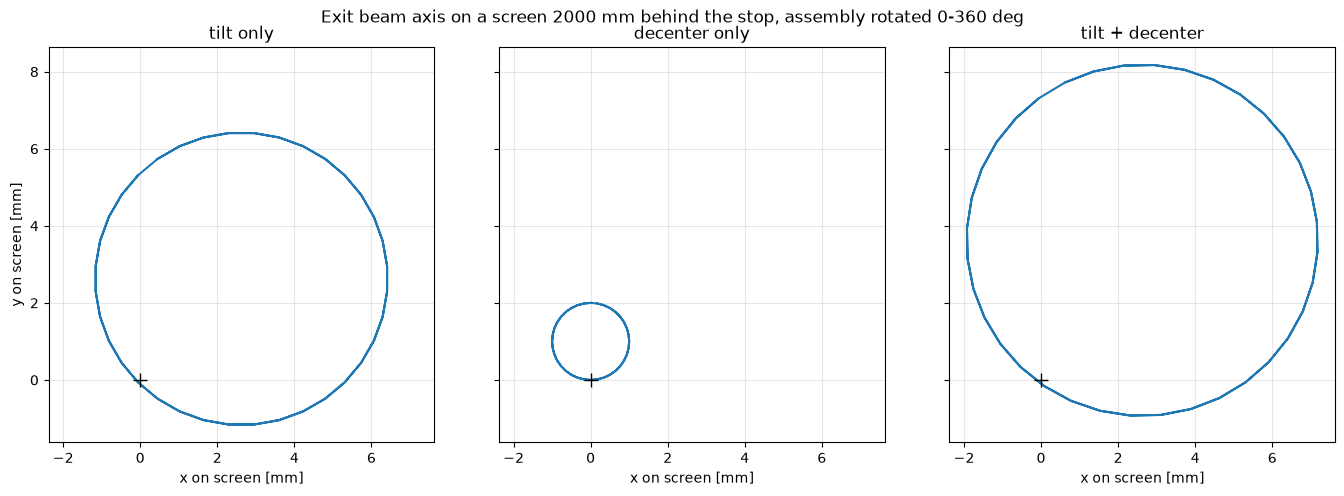

case               |r| min   |r| max         locus centre    radius    rate
tilt only           0.084     7.509 (  +2.625,  +2.625)     3.796  +2.000
decenter only       0.000     2.000 (  -0.000,  +1.000)     1.000  +2.000
tilt + decenter     0.177     9.033 (  +2.625,  +3.625)     4.558  +2.000

Each locus is a circle through the origin, traced at 2 theta: the error
vanishes twice per revolution and peaks at twice its static value. Unlike a
co-rotating error, the response does not depend on the azimuth of the tilt -
the K-mirror sweeps a lab-fixed error through every azimuth anyway.

closed forms, whatever the azimuth:
  tilt      peak = 2 * arm_centre * tan(eps) = 2 * 2151.0 * tan(0.1 deg) = 7.509 mm
  decenter  peak = 2 * d                     = 2.000 mm


In [7]:
TILT = 0.1      # rigid-body tilt of the bearing axis [deg]
TILT_AZ = 45.0  # azimuth of that tilt [deg]
DECENTER = 1.0  # rigid-body decenter of the bearing axis [mm]
thetas = np.arange(0, 360, 5.0)   # no duplicated endpoint -> unbiased centroid


def axis_locus(thetas=thetas, errors=None, pose=None):
    """Screen position of the input beam's geometric axis vs assembly rotation."""
    out = []
    for th in thetas:
        o = build(theta=th, errors=errors, pose=pose, aiming=None)  # own rays
        rays = axial_rays()                        # ray 0 is the axis ray
        o.surfaces.trace(rays, skip=1)             # skip the object surface
        s = o.surfaces.surfaces[5]
        out.append((float(np.asarray(s.x)[0]), float(np.asarray(s.y)[0])))
    return np.array(out)


def azimuth_rate(d, thetas=thetas):
    """deg of locus azimuth per deg of assembly rotation."""
    ang = np.unwrap(np.arctan2(d[:, 1] - d[:, 1].mean(), d[:, 0] - d[:, 0].mean()))
    return np.polyfit(thetas, np.degrees(ang), 1)[0]


# a perfectly placed assembly must give exactly zero pointing error
d0 = axis_locus(pose=None)
print(f"no misalignment: max |r| = {np.hypot(*d0.T).max():.2e} mm  (expect 0)\n")

cases = {"tilt only": dict(tilt=TILT, tilt_az=TILT_AZ),
         "decenter only": dict(dy=DECENTER),
         "tilt + decenter": dict(tilt=TILT, tilt_az=TILT_AZ, dy=DECENTER)}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), sharex=True, sharey=True)
for ax, (label, kw) in zip(axes, cases.items()):
    d = axis_locus(pose=kw)
    ax.plot(d[:, 0], d[:, 1], "-", lw=1.5)
    ax.plot(0, 0, "k+", ms=10)
    ax.set_title(label)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.set_xlabel("x on screen [mm]")
axes[0].set_ylabel("y on screen [mm]")
fig.suptitle(f"Exit beam axis on a screen {SCREEN:g} mm behind the stop, "
             f"assembly rotated 0-360 deg")
plt.tight_layout()
plt.show()

print(f"{'case':16s} {'|r| min':>9} {'|r| max':>9} {'locus centre':>20} "
      f"{'radius':>9} {'rate':>7}")
for label, kw in cases.items():
    d = axis_locus(pose=kw)
    r = np.hypot(*d.T)
    cx, cy = d[:, 0].mean(), d[:, 1].mean()
    rc = np.hypot(d[:, 0] - cx, d[:, 1] - cy).mean()
    print(f"{label:16s} {r.min():8.3f} {r.max():9.3f} "
          f"({cx:+8.3f},{cy:+8.3f}) {rc:9.3f} {azimuth_rate(d):+7.3f}")

# folded distance from the assembly centre (the pivot) to the screen
ARM_CENTRE = 0.5 * X_TOTAL / np.cos(2 * a) + STOP_AFTER_M3 + SCREEN
print("\nEach locus is a circle through the origin, traced at 2 theta: the error")
print("vanishes twice per revolution and peaks at twice its static value. Unlike a")
print("co-rotating error, the response does not depend on the azimuth of the tilt -")
print("the K-mirror sweeps a lab-fixed error through every azimuth anyway.")
print(f"\nclosed forms, whatever the azimuth:")
print(f"  tilt      peak = 2 * arm_centre * tan(eps) = "
      f"2 * {ARM_CENTRE:.1f} * tan({TILT} deg) = "
      f"{2 * ARM_CENTRE * np.tan(np.radians(TILT)):.3f} mm")
print(f"  decenter  peak = 2 * d                     = {2 * DECENTER:.3f} mm")

### 5.1 Pointing error in angular units

The **angular pointing error** is the angle between the exit beam and the nominal optical
axis - the intrinsic quantity, independent of where you put a screen. A mirror tilted by
$\varepsilon$ deflects the beam by $2\varepsilon$ in its plane of incidence and by
$2\varepsilon\cos(\mathrm{AOI})$ out of it, so 0.1 deg of mirror tilt is 12.0 arcmin of
beam deviation no matter which of the three mirrors it is on.

Displacement on a screen is that angle times a lever arm. Because the beam pivots **at
the mistilted element**, not at the stop, the arm differs slightly per element, so the
angle inferred from the screen spot assuming a 2 m arm, $\arctan(r/D)$, runs a few per
cent above the true deviation. The converters below use that screen convention, which is
what a camera 2 m away actually measures; `exit_angle` returns the true deviation from
the exit ray direction if you need the distinction.

In [8]:
RAD2AMIN = np.degrees(1.0) * 60.0


def mm_to_amin(v):
    return np.degrees(np.arctan2(np.asarray(v, dtype=float), SCREEN)) * 60.0


def amin_to_mm(v):
    return SCREEN * np.tan(np.radians(np.asarray(v, dtype=float) / 60.0))


def exit_angle(err=None, th=0.0, pose=None):
    """(deviation, azimuth) of the exit beam axis in deg, from ray directions.

    This is the true angular deviation, not the screen-inferred one.
    """
    o = build(theta=th, errors=err, pose=pose, aiming=None)
    rays = axial_rays()
    o.surfaces.trace(rays, skip=1)
    s = o.surfaces.surfaces[5]
    L, M, N = (float(np.asarray(v)[0]) for v in (s.L, s.M, s.N))
    return np.degrees(np.arccos(min(1.0, abs(N)))), np.degrees(np.arctan2(M, L))

## 6. Monte Carlo over the full tolerance budget

Everything misaligned at once, at random, within these bounds:

| degree of freedom | count | tolerance |
| --- | --- | --- |
| bearing-axis tip about $x$ and about $y$ | 2 | $\pm 0.1^\circ$ |
| bearing-axis decenter $d_x$, $d_y$ | 2 | $\pm 1$ mm |
| per-mirror tilt $\varepsilon_x$, $\varepsilon_y$ (M1, M2, M3, own frames) | 6 | $\pm 0.1^\circ$ |

Ten independent degrees of freedom, each drawn **uniformly** inside its band - the
mechanical reading of a tolerance as a hard bound rather than a standard deviation. A
Gaussian draw with $\sigma = $ tol/3 would give a tighter distribution with a longer tail;
change `rng.uniform` to `rng.normal` to see it.

The two families behave differently over a revolution. The **assembly pose** is fixed in
the lab, so it sweeps at 2&theta;. The **per-mirror tilts** are bolted to the mirrors, so
they spin with the assembly and sweep at 1&theta;. The total is therefore not a simple
circle: the 2&theta; and 1&theta; terms beat against each other, and the pointing error
swings between a minimum and a maximum once per revolution.

random tolerance state (seed 4):
  bearing tilt      0.0886 deg at azimuth +1.5 deg
  bearing decenter  (+0.952, -0.838) mm
  M1 local ex, ey  (+0.0215, -0.0247) deg
  M2 local ex, ey  (+0.0604, -0.0651) deg
  M3 local ex, ey  (+0.0743, +0.0088) deg

  |r| =   3.479 ..  11.804 mm  (mean   7.051 mm = 12.12', rms   7.541 mm)


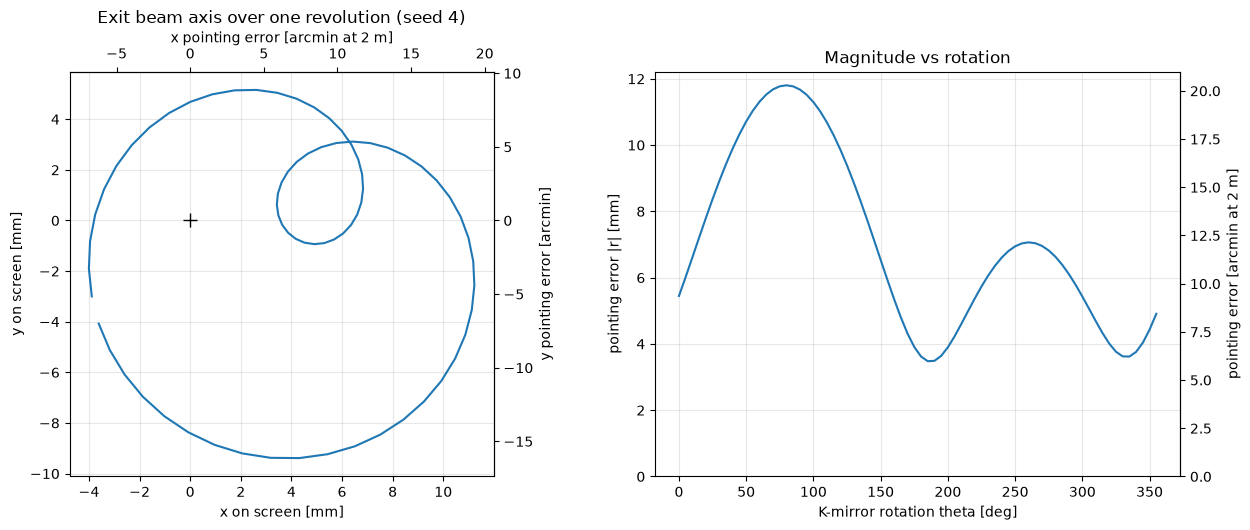


The locus is not a circle: the 2 theta bearing term and the 1 theta
per-mirror term beat, so the magnitude swings over the revolution.


In [9]:
TOL_ANG = 0.1   # tolerance on every angular DOF [deg]
TOL_DEC = 1.0   # tolerance on assembly decenter [mm]
SEED = 4


def draw_state(rng):
    """One random tolerance state; every DOF uniform inside +/- its tolerance."""
    tx, ty = rng.uniform(-TOL_ANG, TOL_ANG, 2)      # bearing-axis tip about x, y
    dx, dy = rng.uniform(-TOL_DEC, TOL_DEC, 2)      # bearing-axis decenter
    pose = dict(tilt=float(np.hypot(tx, ty)),
                tilt_az=float(np.degrees(np.arctan2(ty, tx))),
                dx=float(dx), dy=float(dy))
    errors = rng.uniform(-TOL_ANG, TOL_ANG, (3, 2))  # per-mirror local tilts
    return pose, errors


pose, errors = draw_state(np.random.default_rng(SEED))
print(f"random tolerance state (seed {SEED}):")
print(f"  bearing tilt      {pose['tilt']:.4f} deg at azimuth "
      f"{pose['tilt_az']:+.1f} deg")
print(f"  bearing decenter  ({pose['dx']:+.3f}, {pose['dy']:+.3f}) mm")
for i in range(3):
    print(f"  M{i + 1} local ex, ey  ({errors[i, 0]:+.4f}, {errors[i, 1]:+.4f}) deg")

d = axis_locus(errors=errors, pose=pose)
r = np.hypot(*d.T)
print(f"\n  |r| = {r.min():7.3f} .. {r.max():7.3f} mm  "
      f"(mean {r.mean():7.3f} mm = {mm_to_amin(r.mean()):5.2f}', "
      f"rms {np.sqrt((r ** 2).mean()):7.3f} mm)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
axes[0].plot(d[:, 0], d[:, 1], "-", lw=1.5)
axes[1].plot(thetas, r, lw=1.5)

axes[0].plot(0, 0, "k+", ms=10)
axes[0].set_aspect("equal")
axes[0].set_xlabel("x on screen [mm]")
axes[0].set_ylabel("y on screen [mm]")
axes[0].set_title(f"Exit beam axis over one revolution (seed {SEED})")
axes[0].grid(alpha=0.3)
secx = axes[0].secondary_xaxis("top", functions=(mm_to_amin, amin_to_mm))
secx.set_xlabel("x pointing error [arcmin at 2 m]")
secy = axes[0].secondary_yaxis("right", functions=(mm_to_amin, amin_to_mm))
secy.set_ylabel("y pointing error [arcmin]")

axes[1].set_xlabel("K-mirror rotation theta [deg]")
axes[1].set_ylabel("pointing error |r| [mm]")
axes[1].set_title("Magnitude vs rotation")
axes[1].grid(alpha=0.3)
axes[1].set_ylim(bottom=0)
secy2 = axes[1].secondary_yaxis("right", functions=(mm_to_amin, amin_to_mm))
secy2.set_ylabel("pointing error [arcmin at 2 m]")

plt.tight_layout()
plt.show()

print("\nThe locus is not a circle: the 2 theta bearing term and the 1 theta")
print("per-mirror term beat, so the magnitude swings over the revolution.")

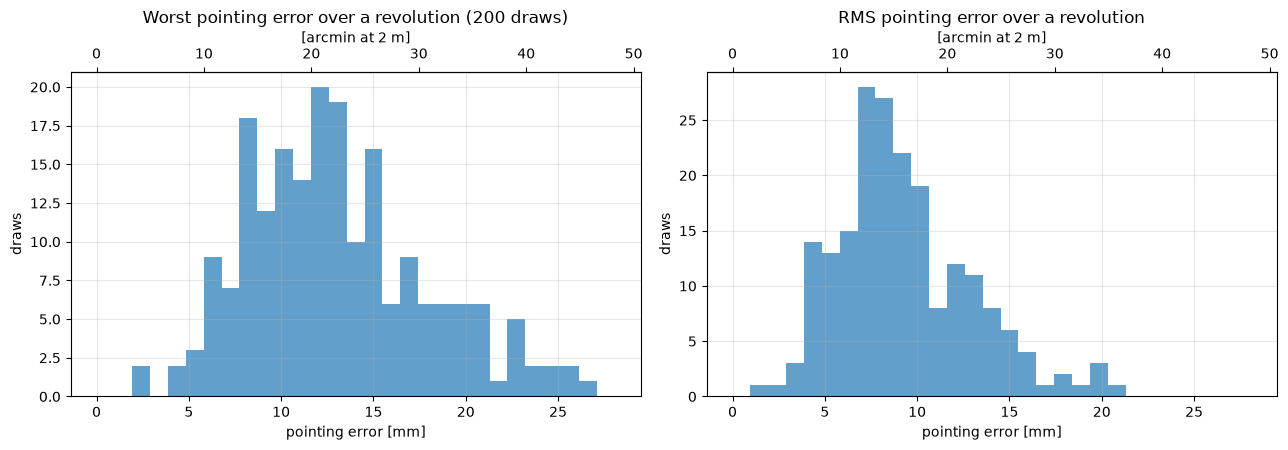

  metric           median         95th pct              max
   worst    12.31 mm 21.17'    22.46 mm 38.60'    26.73 mm 45.94'
     rms     8.65 mm 14.86'    15.83 mm 27.21'    20.63 mm 35.46'

for reference, a single 0.1 deg mirror tilt alone gives 13.2' (7.7 mm).


In [10]:
N_TRIALS = 200
th_mc = np.arange(0, 360, 10.0)     # coarser sweep; 200 x 36 traces

rng = np.random.default_rng(SEED + 1)
worst, rms_r = [], []
for _ in range(N_TRIALS):
    pose_i, err_i = draw_state(rng)
    r = np.hypot(*axis_locus(thetas=th_mc, errors=err_i, pose=pose_i).T)
    worst.append(r.max())
    rms_r.append(np.sqrt((r ** 2).mean()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
bins = np.linspace(0, max(worst) * 1.05, 30)
axes[0].hist(worst, bins=bins, alpha=0.7)
axes[1].hist(rms_r, bins=bins, alpha=0.7)
axes[0].set_title(f"Worst pointing error over a revolution ({N_TRIALS} draws)")
axes[1].set_title("RMS pointing error over a revolution")
for ax in axes:
    ax.set_xlabel("pointing error [mm]")
    ax.set_ylabel("draws")
    ax.grid(alpha=0.3)
    sec = ax.secondary_xaxis("top", functions=(mm_to_amin, amin_to_mm))
    sec.set_xlabel("[arcmin at 2 m]")
plt.tight_layout()
plt.show()

print(f"{'metric':>8} {'median':>16} {'95th pct':>16} {'max':>16}")
for metric, vals in (("worst", worst), ("rms", rms_r)):
    v = np.array(vals)
    med, p95, mx = np.median(v), np.percentile(v, 95), v.max()
    print(f"{metric:>8} "
          f"{med:8.2f} mm {mm_to_amin(med):5.2f}' "
          f"{p95:8.2f} mm {mm_to_amin(p95):5.2f}' "
          f"{mx:8.2f} mm {mm_to_amin(mx):5.2f}'")

print(f"\nfor reference, a single 0.1 deg mirror tilt alone gives "
      f"{mm_to_amin(7.7):.1f}' ({7.7:.1f} mm).")

## 7. Which errors dominate

Each of the ten degrees of freedom is driven to its full tolerance **one at a time**, with
everything else perfect, and the resulting pointing error is measured. The response turns
out to be exactly linear in every DOF (checked below), so this one-at-a-time table is a
complete description: any combined state is the vector sum of the individual responses.

Each response is quoted as the **RMS over a revolution**, since the lab-fixed terms vary
with $\theta$ while the co-rotating mirror terms do not, and the RMS is what compares
fairly between them. The share of the total variance carried by each DOF follows from
those RMS values; the ensemble in section 6 is the independent check on the whole picture.

           DOF    tolerance    rms over theta      mean       max
 bearing tip x     0.10 deg    5.310 mm  9.13'  4.780 mm  7.509 mm
 bearing tip y     0.10 deg    5.310 mm  9.13'  4.780 mm  7.509 mm
    bearing dx     1.00 mm     1.414 mm  2.43'  1.272 mm  2.000 mm
    bearing dy     1.00 mm     1.414 mm  2.43'  1.272 mm  2.000 mm
         M1 ex     0.10 deg    7.687 mm 13.21'  7.687 mm  7.687 mm
         M1 ey     0.10 deg    3.727 mm  6.41'  3.727 mm  3.727 mm
         M2 ex     0.10 deg    7.509 mm 12.91'  7.509 mm  7.509 mm
         M2 ey     0.10 deg    6.368 mm 10.95'  6.368 mm  6.368 mm
         M3 ex     0.10 deg    7.330 mm 12.60'  7.330 mm  7.330 mm
         M3 ey     0.10 deg    3.554 mm  6.11'  3.554 mm  3.554 mm

linearity check (rms |r| at 1/4, 1/2 and full tolerance):
  bearing tip y:  1.3274  2.6548  5.3097 mm   ratios 2.000, 2.000  (expect 2.000)
          M1 ex:  1.9217  3.8434  7.6868 mm   ratios 2.000, 2.000  (expect 2.000)
     bearing dy:  0.3536  0.7071  1.4142 

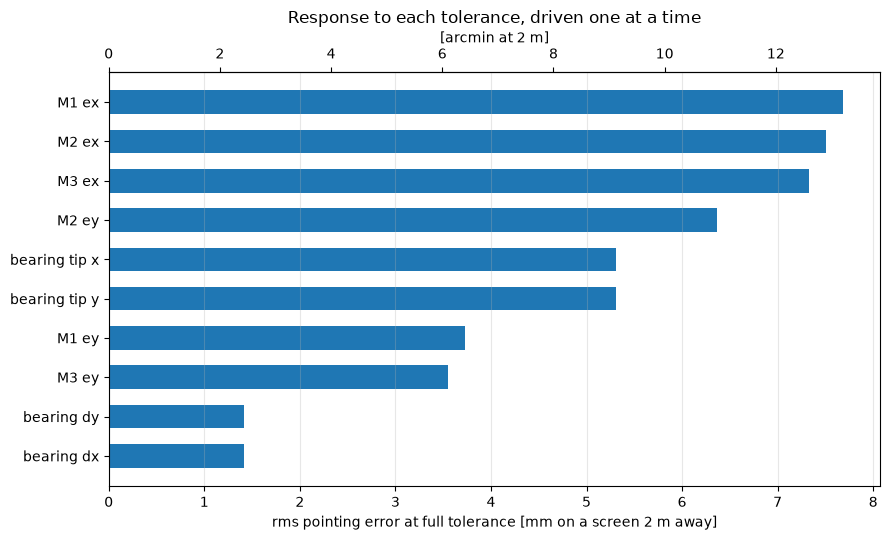


share of the total variance:
           M1 ex   7.687 mm    19.9 %   (cumulative  19.9 %)
           M2 ex   7.509 mm    19.0 %   (cumulative  38.9 %)
           M3 ex   7.330 mm    18.1 %   (cumulative  57.0 %)
           M2 ey   6.368 mm    13.7 %   (cumulative  70.7 %)
   bearing tip x   5.310 mm     9.5 %   (cumulative  80.2 %)
   bearing tip y   5.310 mm     9.5 %   (cumulative  89.7 %)
           M1 ey   3.727 mm     4.7 %   (cumulative  94.4 %)
           M3 ey   3.554 mm     4.3 %   (cumulative  98.7 %)
      bearing dy   1.414 mm     0.7 %   (cumulative  99.3 %)
      bearing dx   1.414 mm     0.7 %   (cumulative 100.0 %)


In [11]:
def dof_state(name, mag):
    """(pose, errors) with a single degree of freedom set to `mag`."""
    if name == "bearing tip x":
        return dict(tilt=mag, tilt_az=0.0), None
    if name == "bearing tip y":
        return dict(tilt=mag, tilt_az=90.0), None
    if name == "bearing dx":
        return dict(dx=mag), None
    if name == "bearing dy":
        return dict(dy=mag), None
    mirror, axis = name.split()               # e.g. "M2 ey"
    errors = np.zeros((3, 2))
    errors[int(mirror[1]) - 1, "xy".index(axis[1])] = mag
    return None, errors


DOFS = [("bearing tip x", TOL_ANG, "deg"), ("bearing tip y", TOL_ANG, "deg"),
        ("bearing dx", TOL_DEC, "mm"), ("bearing dy", TOL_DEC, "mm")]
DOFS += [(f"M{i} e{ax}", TOL_ANG, "deg") for i in (1, 2, 3) for ax in "xy"]

# the RMS over a revolution is the quantity that adds in quadrature, so it is
# what the budget below is built from; mean and max are shown for context
resp = {}
print(f"{'DOF':>14} {'tolerance':>12} {'rms over theta':>17} {'mean':>9} "
      f"{'max':>9}")
for name, tol, unit in DOFS:
    pose, errors = dof_state(name, tol)
    r = np.hypot(*axis_locus(errors=errors, pose=pose).T)
    resp[name] = np.sqrt((r ** 2).mean())
    print(f"{name:>14} {tol:8.2f} {unit:3s} {resp[name]:8.3f} mm "
          f"{mm_to_amin(resp[name]):5.2f}' {r.mean():6.3f} mm {r.max():6.3f} mm")

# --- the response is linear, so one coefficient per DOF says everything ---
print("\nlinearity check (rms |r| at 1/4, 1/2 and full tolerance):")
for name in ("bearing tip y", "M1 ex", "bearing dy"):
    tol = TOL_DEC if name.startswith("bearing d") else TOL_ANG
    v = []
    for f in (0.25, 0.5, 1.0):
        pose, errors = dof_state(name, f * tol)
        r = np.hypot(*axis_locus(errors=errors, pose=pose).T)
        v.append(np.sqrt((r ** 2).mean()))
    print(f"  {name:>13}: {v[0]:7.4f} {v[1]:7.4f} {v[2]:7.4f} mm   "
          f"ratios {v[1] / v[0]:.3f}, {v[2] / v[1]:.3f}  (expect 2.000)")

# --- ranked contributions -------------------------------------------------
order = sorted(resp, key=lambda k: -resp[k])
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(y, [resp[k] for k in order], 0.6)
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.invert_yaxis()
ax.set_xlabel("rms pointing error at full tolerance [mm on a screen 2 m away]")
ax.set_title("Response to each tolerance, driven one at a time")
ax.grid(alpha=0.3, axis="x")
sec = ax.secondary_xaxis("top", functions=(mm_to_amin, amin_to_mm))
sec.set_xlabel("[arcmin at 2 m]")
plt.tight_layout()
plt.show()

total_var = sum(v ** 2 for v in resp.values())
print("\nshare of the total variance:")
cum = 0.0
for name in order:
    share = 100 * resp[name] ** 2 / total_var
    cum += share
    print(f"  {name:>14} {resp[name]:7.3f} mm   {share:5.1f} %   "
          f"(cumulative {cum:5.1f} %)")

### 7.1 Can M2 alone compensate?

M2 is the natural compensator: it is the one mirror a K-mirror mount can usually reach
with two pusher screws without disturbing the fold geometry. So ask whether tipping M2 by
$(\varepsilon_x, \varepsilon_y)$ can cancel a random draw of all the other errors.

The response is linear in every degree of freedom (section 7), so the corrected locus is

$$\mathbf{r}(\theta) = \mathbf{r}_0(\theta)
  + \varepsilon_x \mathbf{J}_x(\theta) + \varepsilon_y \mathbf{J}_y(\theta)$$

with $\mathbf{r}_0$ the locus with M2 perfect and $\mathbf{J}$ the M2 response per degree.
Minimising the RMS of $|\mathbf{r}|$ over a revolution is then an ordinary two-parameter
least-squares problem - no iterative optimiser needed, and the solution is the global
optimum.

The answer is bounded in advance by the $\theta$ dependence. M2 spins with the assembly,
so its response is a $1\theta$ term. It can therefore only attack the $1\theta$ part of
the error - the other mirrors' tilts - and is blind to the $2\theta$ bearing term, which
no static tilt of any mirror can remove.

seed 4: M2 correction ex = +0.0945, ey = -0.0096 deg (tolerance 0.1 deg)
  as drawn           rms   7.541 mm   |r|  3.479 ..  11.804 mm
  M2 zeroed          rms   9.409 mm   |r|  0.581 ..  15.800 mm
  M2 optimised       rms   6.145 mm   |r|  0.071 ..   8.691 mm
  bearing pose only  rms   6.145 mm   |r|  0.073 ..   8.690 mm


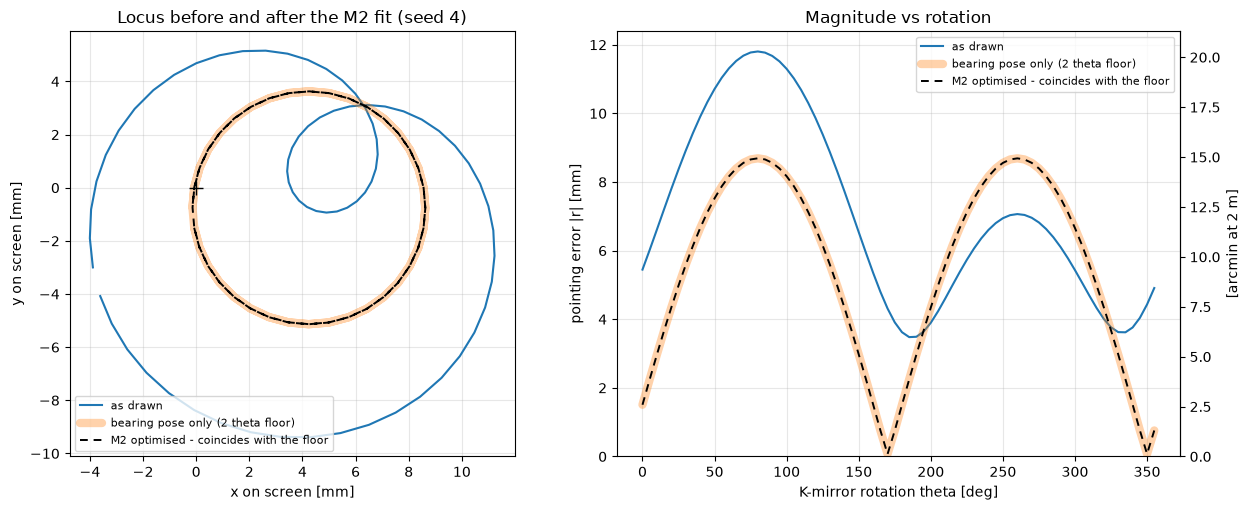


30 random draws, M2 (ex, ey) fitted to each:
                           median   95th pct        max
rms as drawn [mm]           8.856     19.474     19.903
rms corrected [mm]          4.217      6.362      7.972
2 theta floor [mm]          4.217      6.362      7.972
M2 tilt needed [deg]        0.083      0.158      0.169

median improvement factor 2.21x; corrected result sits 1.00x the 2 theta floor
draws needing more than the 0.1 deg tolerance on M2: 37%


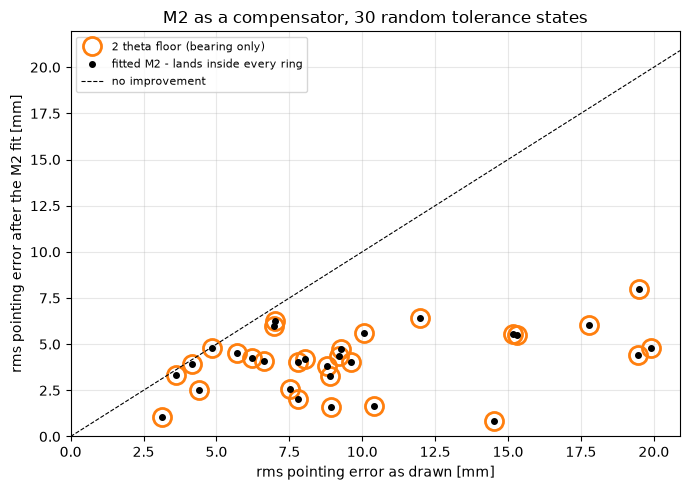

In [12]:
def m2_correction(pose, errors, ths=thetas):
    """Least-squares M2 (ex, ey) [deg] minimising rms |r| over a revolution.

    Linear in the tilts, so this is a 2-parameter least-squares fit, not a search.
    """
    e0 = np.array(errors, dtype=float).copy()
    e0[1] = 0.0                                    # M2 set aside
    r0 = axis_locus(thetas=ths, errors=e0, pose=pose)
    cols = []
    for k in (0, 1):                               # M2 response per degree
        e = np.zeros((3, 2))
        e[1, k] = TOL_ANG
        cols.append(axis_locus(thetas=ths, errors=e).ravel() / TOL_ANG)
    c, *_ = np.linalg.lstsq(np.stack(cols, axis=1), -r0.ravel(), rcond=None)
    return c, e0


def rms(d):
    return float(np.sqrt((d ** 2).sum(axis=1).mean()))


# --- one draw, in detail --------------------------------------------------
pose_c, err_c = draw_state(np.random.default_rng(SEED))
c, e0 = m2_correction(pose_c, err_c)
e_fix = e0.copy()
e_fix[1] = c

before = axis_locus(errors=err_c, pose=pose_c)
after = axis_locus(errors=e_fix, pose=pose_c)
nom2 = axis_locus(errors=e0, pose=pose_c)          # M2 perfect, uncorrected
only_pose = axis_locus(pose=pose_c)                # the 2 theta floor

print(f"seed {SEED}: M2 correction ex = {c[0]:+.4f}, ey = {c[1]:+.4f} deg "
      f"(tolerance {TOL_ANG} deg)")
for name, d in (("as drawn", before), ("M2 zeroed", nom2),
                ("M2 optimised", after), ("bearing pose only", only_pose)):
    r = np.hypot(*d.T)
    print(f"  {name:18s} rms {rms(d):7.3f} mm   |r| {r.min():6.3f} .. "
          f"{r.max():7.3f} mm")

# "M2 optimised" lands on "bearing pose only" to three digits, so draw the
# floor as a broad pale band and the fit as a thin dashed line on top of it -
# seeing the dashes sit inside the band *is* the result
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
styles = (("as drawn", before, dict(lw=1.5, color="tab:blue")),
          ("bearing pose only (2 theta floor)", only_pose,
           dict(lw=6, color="tab:orange", alpha=0.35, solid_capstyle="round")),
          ("M2 optimised - coincides with the floor", after,
           dict(lw=1.4, color="k", ls=(0, (4, 3)))))
for name, d, kw in styles:
    axes[0].plot(d[:, 0], d[:, 1], label=name, **kw)
    axes[1].plot(thetas, np.hypot(*d.T), label=name, **kw)
axes[0].plot(0, 0, "k+", ms=10)
axes[0].set_aspect("equal")
axes[0].set_xlabel("x on screen [mm]")
axes[0].set_ylabel("y on screen [mm]")
axes[0].set_title(f"Locus before and after the M2 fit (seed {SEED})")
axes[1].set_xlabel("K-mirror rotation theta [deg]")
axes[1].set_ylabel("pointing error |r| [mm]")
axes[1].set_title("Magnitude vs rotation")
axes[1].set_ylim(bottom=0)
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
sec = axes[1].secondary_yaxis("right", functions=(mm_to_amin, amin_to_mm))
sec.set_ylabel("[arcmin at 2 m]")
plt.tight_layout()
plt.show()

# --- over an ensemble of draws -------------------------------------------
N_FIT = 30
th_fit = np.arange(0, 360, 15.0)                   # coarser sweep for the loop
rng = np.random.default_rng(SEED + 2)
rows = []
for _ in range(N_FIT):
    p_i, e_i = draw_state(rng)
    c_i, e0_i = m2_correction(p_i, e_i, ths=th_fit)
    e_fix_i = e0_i.copy()
    e_fix_i[1] = c_i
    rows.append((rms(axis_locus(thetas=th_fit, errors=e_i, pose=p_i)),
                 rms(axis_locus(thetas=th_fit, errors=e_fix_i, pose=p_i)),
                 rms(axis_locus(thetas=th_fit, pose=p_i)),
                 float(np.hypot(*c_i))))
before_r, after_r, floor_r, mag = (np.array(v) for v in zip(*rows))

print(f"\n{N_FIT} random draws, M2 (ex, ey) fitted to each:")
print(f"{'':22s} {'median':>10} {'95th pct':>10} {'max':>10}")
for name, v in (("rms as drawn [mm]", before_r), ("rms corrected [mm]", after_r),
                ("2 theta floor [mm]", floor_r),
                ("M2 tilt needed [deg]", mag)):
    print(f"{name:22s} {np.median(v):10.3f} {np.percentile(v, 95):10.3f} "
          f"{v.max():10.3f}")
print(f"\nmedian improvement factor {np.median(before_r / after_r):.2f}x; "
      f"corrected result sits {np.median(after_r / floor_r):.2f}x the 2 theta floor")
print(f"draws needing more than the {TOL_ANG} deg tolerance on M2: "
      f"{100 * np.mean(mag > TOL_ANG):.0f}%")

fig, ax = plt.subplots(figsize=(7, 5))
# every fitted point falls on its own floor point, so plot the floor as a large
# open ring and the fit as a small dot centred in it
ax.plot(before_r, floor_r, "o", ms=13, mfc="none", mec="tab:orange", mew=2,
        ls="none", label="2 theta floor (bearing only)")
ax.plot(before_r, after_r, "o", ms=4, color="k", ls="none",
        label="fitted M2 - lands inside every ring")
lim = [0, before_r.max() * 1.05]
ax.plot(lim, lim, "k--", lw=0.8, label="no improvement")
ax.set_xlim(lim)
ax.set_ylim(bottom=0)
ax.set_xlabel("rms pointing error as drawn [mm]")
ax.set_ylabel("rms pointing error after the M2 fit [mm]")
ax.set_title(f"M2 as a compensator, {N_FIT} random tolerance states")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Clipping over the scan

The K-mirror is **perfectly aligned** here - no pose error, no mirror tilts. The only
question is geometric: does the collimated beam get past the three flats over the scan?

**The scan is defined in the default $YZ$ convention**: the field angle is $(0, u)$, so the
beam tilts in the $y$-$z$ meridional plane and `Hy` drives it. At $\theta = 0$ the K also
folds in $YZ$, so the scan starts out **in the fold plane** - the worst orientation.

The on-axis limit is $D_{max} = L\sin\alpha = 24.97$ mm. A field angle spends that margin:
the chief ray at $u$ walks $\mathrm{arm}\times\tan u$ across M1, and because M1 is seen at
$61^\circ$, that walk is magnified by $1/\sin\alpha = 2.06$ when it points along the fold.
The available in-plane margin is only $(L - D/\sin\alpha)/2$, so the walk runs out quickly.
Whether it costs light depends on the assembly rotation $\theta$, so the scan and the
rotation are swept together.

**Both field signs must be traced.** Optiland derives the traced field from `(Hx, Hy)`
times the maximum *radial* field, so the tuples given to `fields.add()` only set the scale
- they do not select which field is traced. `Hy=+1` and `Hy=-1` are genuinely different
geometries here (M2 sits on one side only), and they differ by several percentage points
at a given $\theta$; their curves are related by a $180^\circ$ shift in $\theta$, which is
why the sweep runs over a full turn.

**The stop is opened to the beam** so that only the *mirrors* can vignette. A stop smaller
than the beam would cut it at every field, which is a pupil-sizing question rather than
K-mirror clipping.

D_max = L*sin(alpha)     = 24.97 mm
beam                     = 22.00 mm  (radial margin 1.48 mm on axis)
chief-ray walk at M1     = 6.43 mm (arm 302.1 mm), 13.27 mm along the mirror
chief-ray walk at M3     = 2.13 mm (arm 100 mm)
in-fold-plane margin     = (L - 22/sin(alpha))/2 = 3.06 mm
perpendicular margin     = (L - 22)/2 = 14.75 mm


C:\Users\peter\AppData\Local\Temp\ipykernel_11296\784882730.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


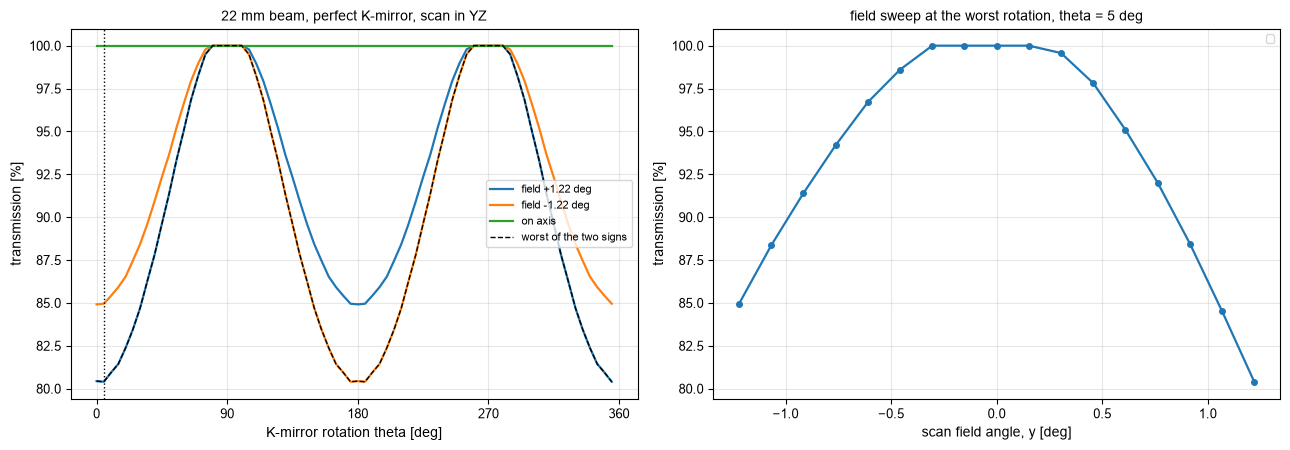


worst transmission 80.40% at theta = 5 deg, field +1.22 deg
on-axis transmission over all theta: 100.00%
the two signs differ by up to 4.55 percentage points - tracing only one of them understates the loss
clipping-free rotations: theta = 80..280 deg

incremental loss per surface at field +1.22 deg:
  theta       M1       M2       M3     stop         T
    5.0   19.60%    0.00%    0.00%    0.00%    80.40%
   30.0   15.30%    0.00%    0.00%    0.00%    84.70%
   60.0    4.98%    0.00%    0.00%    0.00%    95.02%
   90.0    0.00%    0.00%    0.00%    0.00%   100.00%
  120.0    3.40%    0.00%    0.00%    0.00%    96.60%
  150.0   11.57%    0.00%    0.00%    0.00%    88.43%

incremental loss per surface at field 1.22 deg:
  theta       M1       M2       M3     stop         T
    5.0   15.05%    0.00%    0.00%    0.00%    84.95%
   30.0   11.57%    0.00%    0.00%    0.00%    88.43%
   60.0    3.40%    0.00%    0.00%    0.00%    96.60%
   90.0    0.00%    0.00%    0.00%    0.00%   100.00%
 

In [43]:
BEAM = EPD      # beam diameter for this section [mm]; follows the global EPD
SCAN = 1.22     # scan half-angle [deg]
#SCAN = 3.5     # scan half-angle [deg]

print(f"D_max = L*sin(alpha)     = {D_MAX:.2f} mm")
print(f"beam                     = {BEAM:.2f} mm  "
      f"(radial margin {(D_MAX - BEAM) / 2:.2f} mm on axis)")
print(f"chief-ray walk at M1     = {ARM_M1_TO_STOP * np.tan(np.radians(SCAN)):.2f} mm "
      f"(arm {ARM_M1_TO_STOP:.1f} mm), "
      f"{ARM_M1_TO_STOP * np.tan(np.radians(SCAN)) / np.sin(a):.2f} mm along the mirror")
print(f"chief-ray walk at M3     = "
      f"{STOP_AFTER_M3 * np.tan(np.radians(SCAN)):.2f} mm (arm {STOP_AFTER_M3:.0f} mm)")
print(f"in-fold-plane margin     = (L - {BEAM:g}/sin(alpha))/2 = "
      f"{(L - BEAM / np.sin(a)) / 2:.2f} mm")
print(f"perpendicular margin     = (L - {BEAM:g})/2 = {(L - BEAM) / 2:.2f} mm")


def trace_field(theta, hy, epd=BEAM, n=30):
    """Trace a filled hexapolar bundle at NORMALISED meridional field `hy`.

    The scan is in the YZ plane, so the field is (0, u) and `Hy` drives it.
    Optiland computes the traced field as (Hx, Hy) times the maximum *radial*
    field of the group, so the field list here only fixes max_field = SCAN;
    passing Hy=1 with a list of ((0,0), (0,-SCAN)) would trace +SCAN, not
    -SCAN. Driving `hy` directly is the only way to control the sign.

    Args:
        theta: assembly rotation [deg].
        hy: normalised meridional field coordinate; +/-1 are the scan extremes.
        epd: beam diameter [mm], which also sets the stop radius.
        n: hexapolar ring count.

    Returns:
        Optic: traced system.
    """
    o = build(theta=theta, fields=((0.0, 0.0), (0.0, SCAN)), epd=epd)
    o.trace(Hx=0.0, Hy=hy, wavelength=WAVELENGTH, num_rays=n,
            distribution="hexapolar")
    return o


def incremental_loss(o):
    """Percent of the bundle first blocked at each surface, and what survives."""
    prev = np.asarray(o.surfaces.surfaces[1].intensity) > -1   # all True
    out = {}
    for idx in (1, 2, 3, 4):
        ok = np.asarray(o.surfaces.surfaces[idx].intensity) > 0
        out[idx] = 100 * np.mean(prev & ~ok)
        prev = prev & ok
    return out, 100 * np.mean(prev)


def local_xy(o, idx):
    """Ray intersections on surface `idx`, expressed in that mirror's own frame."""
    surf = o.surfaces.surfaces[idx]
    t, R = surf.geometry.cs.get_effective_transform()
    p = np.stack([np.asarray(surf.x), np.asarray(surf.y), np.asarray(surf.z)])
    loc = np.asarray(R).T @ (p - np.asarray(t).reshape(3, 1))
    return loc[0], loc[1], np.asarray(surf.intensity)


# a full turn, because the two field signs are related by a 180 deg shift
th_scan = np.arange(0, 360, 5.0)
curves = {h: np.array([incremental_loss(trace_field(t, h))[1] for t in th_scan])
          for h in (-1.0, 0.0, 1.0)}

envelope = np.minimum(curves[1.0], curves[-1.0])
worst_i = envelope.argmin()
TH_WORST = th_scan[worst_i]
H_WORST = 1.0 if curves[1.0][worst_i] <= curves[-1.0][worst_i] else -1.0

hs = np.linspace(-1.0, 1.0, 17)
by_field = np.array([incremental_loss(trace_field(TH_WORST, h))[1] for h in hs])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for h, lbl in ((1.0, f"field +{SCAN} deg"), (-1.0, f"field -{SCAN} deg"),
               (0.0, "on axis")):
    axes[0].plot(th_scan, curves[h], lw=1.6, label=lbl)
axes[0].plot(th_scan, envelope, "k--", lw=1, label="worst of the two signs")
axes[0].axvline(TH_WORST, color="k", ls=":", lw=1)
axes[0].set_xlabel("K-mirror rotation theta [deg]")
axes[0].set_ylabel("transmission [%]")
axes[0].set_title(f"{BEAM:g} mm beam, perfect K-mirror, scan in YZ")
axes[0].set_xticks(range(0, 361, 90))
axes[1].plot(hs * SCAN, by_field, "-o", ms=4, lw=1.6)
axes[1].set_xlabel("scan field angle, y [deg]")
axes[1].set_ylabel("transmission [%]")
axes[1].set_title(f"field sweep at the worst rotation, theta = {TH_WORST:g} deg")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nworst transmission {envelope[worst_i]:.2f}% at theta = {TH_WORST:g} deg, "
      f"field {H_WORST * SCAN:+.2f} deg")
print(f"on-axis transmission over all theta: {curves[0.0].min():.2f}%")
print(f"the two signs differ by up to "
      f"{np.abs(curves[1.0] - curves[-1.0]).max():.2f} percentage points - "
      f"tracing only one of them understates the loss")
clean = th_scan[envelope > 99.999]
if len(clean):
    print(f"clipping-free rotations: theta = {clean.min():g}..{clean.max():g} deg")

print(f"\nincremental loss per surface at field {H_WORST * SCAN:+.2f} deg:")
print(f"{'theta':>7} {'M1':>8} {'M2':>8} {'M3':>8} {'stop':>8} {'T':>9}")
for t in (TH_WORST, 30.0, 60.0, 90.0, 120.0, 150.0):
    loss, T = incremental_loss(trace_field(t, H_WORST))
    print(f"{t:7.1f} {loss[1]:7.2f}% {loss[2]:7.2f}% {loss[3]:7.2f}% "
          f"{loss[4]:7.2f}% {T:8.2f}%")

print(f"\nincremental loss per surface at field {H_WORST * SCAN:-.2f} deg:")
print(f"{'theta':>7} {'M1':>8} {'M2':>8} {'M3':>8} {'stop':>8} {'T':>9}")
for t in (TH_WORST, 30.0, 60.0, 90.0, 120.0, 150.0):
    loss, T = incremental_loss(trace_field(t, -H_WORST))
    print(f"{t:7.1f} {loss[1]:7.2f}% {loss[2]:7.2f}% {loss[3]:7.2f}% "
          f"{loss[4]:7.2f}% {T:8.2f}%")

D_max = L*sin(alpha)     = 24.97 mm
beam                     = 22.00 mm  (radial margin 1.48 mm on axis)
chief-ray walk at M1     = 6.43 mm (arm 302.1 mm), 13.27 mm along the mirror
chief-ray walk at M3     = 2.13 mm (arm 100 mm)
in-fold-plane margin     = (L - 22/sin(alpha))/2 = 3.06 mm
perpendicular margin     = (L - 22)/2 = 14.75 mm


C:\Users\peter\AppData\Local\Temp\ipykernel_11296\2647221252.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


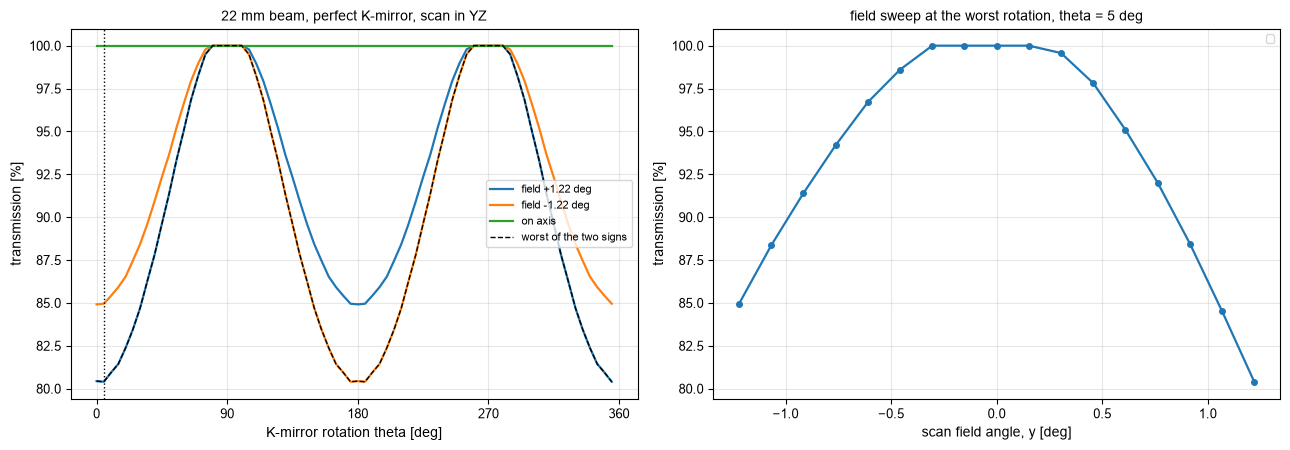


worst transmission 80.40% at theta = 5 deg, field +1.22 deg
on-axis transmission over all theta: 100.00%
the two signs differ by up to 4.55 percentage points - tracing only one of them understates the loss
clipping-free rotations: theta = 80..280 deg

incremental loss per surface at field +1.22 deg:
  theta       M1       M2       M3     stop         T
    5.0   19.60%    0.00%    0.00%    0.00%    80.40%
   30.0   15.30%    0.00%    0.00%    0.00%    84.70%
   60.0    4.98%    0.00%    0.00%    0.00%    95.02%
   90.0    0.00%    0.00%    0.00%    0.00%   100.00%
  120.0    3.40%    0.00%    0.00%    0.00%    96.60%
  150.0   11.57%    0.00%    0.00%    0.00%    88.43%


In [44]:
## Repeat same in order to generate plot

BEAM = EPD      # beam diameter for this section [mm]; follows the global EPD
SCAN = 1.22     # scan half-angle [deg]
#SCAN = 3.5     # scan half-angle [deg]

print(f"D_max = L*sin(alpha)     = {D_MAX:.2f} mm")
print(f"beam                     = {BEAM:.2f} mm  "
      f"(radial margin {(D_MAX - BEAM) / 2:.2f} mm on axis)")
print(f"chief-ray walk at M1     = {ARM_M1_TO_STOP * np.tan(np.radians(SCAN)):.2f} mm "
      f"(arm {ARM_M1_TO_STOP:.1f} mm), "
      f"{ARM_M1_TO_STOP * np.tan(np.radians(SCAN)) / np.sin(a):.2f} mm along the mirror")
print(f"chief-ray walk at M3     = "
      f"{STOP_AFTER_M3 * np.tan(np.radians(SCAN)):.2f} mm (arm {STOP_AFTER_M3:.0f} mm)")
print(f"in-fold-plane margin     = (L - {BEAM:g}/sin(alpha))/2 = "
      f"{(L - BEAM / np.sin(a)) / 2:.2f} mm")
print(f"perpendicular margin     = (L - {BEAM:g})/2 = {(L - BEAM) / 2:.2f} mm")


def trace_field(theta, hy, epd=BEAM, n=30):
    """Trace a filled hexapolar bundle at NORMALISED meridional field `hy`.

    The scan is in the YZ plane, so the field is (0, u) and `Hy` drives it.
    Optiland computes the traced field as (Hx, Hy) times the maximum *radial*
    field of the group, so the field list here only fixes max_field = SCAN;
    passing Hy=1 with a list of ((0,0), (0,-SCAN)) would trace +SCAN, not
    -SCAN. Driving `hy` directly is the only way to control the sign.

    Args:
        theta: assembly rotation [deg].
        hy: normalised meridional field coordinate; +/-1 are the scan extremes.
        epd: beam diameter [mm], which also sets the stop radius.
        n: hexapolar ring count.

    Returns:
        Optic: traced system.
    """
    o = build(theta=theta, fields=((0.0, 0.0), (0.0, SCAN)), epd=epd)
    o.trace(Hx=0.0, Hy=hy, wavelength=WAVELENGTH, num_rays=n,
            distribution="hexapolar")
    return o


def incremental_loss(o):
    """Percent of the bundle first blocked at each surface, and what survives."""
    prev = np.asarray(o.surfaces.surfaces[1].intensity) > -1   # all True
    out = {}
    for idx in (1, 2, 3, 4):
        ok = np.asarray(o.surfaces.surfaces[idx].intensity) > 0
        out[idx] = 100 * np.mean(prev & ~ok)
        prev = prev & ok
    return out, 100 * np.mean(prev)


def local_xy(o, idx):
    """Ray intersections on surface `idx`, expressed in that mirror's own frame."""
    surf = o.surfaces.surfaces[idx]
    t, R = surf.geometry.cs.get_effective_transform()
    p = np.stack([np.asarray(surf.x), np.asarray(surf.y), np.asarray(surf.z)])
    loc = np.asarray(R).T @ (p - np.asarray(t).reshape(3, 1))
    return loc[0], loc[1], np.asarray(surf.intensity)


# a full turn, because the two field signs are related by a 180 deg shift
th_scan = np.arange(0, 360, 5.0)
curves = {h: np.array([incremental_loss(trace_field(t, h))[1] for t in th_scan])
          for h in (-1.0, 0.0, 1.0)}

envelope = np.minimum(curves[1.0], curves[-1.0])
worst_i = envelope.argmin()
TH_WORST = th_scan[worst_i]
H_WORST = 1.0 if curves[1.0][worst_i] <= curves[-1.0][worst_i] else -1.0

hs = np.linspace(-1.0, 1.0, 17)
by_field = np.array([incremental_loss(trace_field(TH_WORST, h))[1] for h in hs])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for h, lbl in ((1.0, f"field +{SCAN} deg"), (-1.0, f"field -{SCAN} deg"),
               (0.0, "on axis")):
    axes[0].plot(th_scan, curves[h], lw=1.6, label=lbl)
axes[0].plot(th_scan, envelope, "k--", lw=1, label="worst of the two signs")
axes[0].axvline(TH_WORST, color="k", ls=":", lw=1)
axes[0].set_xlabel("K-mirror rotation theta [deg]")
axes[0].set_ylabel("transmission [%]")
axes[0].set_title(f"{BEAM:g} mm beam, perfect K-mirror, scan in YZ")
axes[0].set_xticks(range(0, 361, 90))
axes[1].plot(hs * SCAN, by_field, "-o", ms=4, lw=1.6)
axes[1].set_xlabel("scan field angle, y [deg]")
axes[1].set_ylabel("transmission [%]")
axes[1].set_title(f"field sweep at the worst rotation, theta = {TH_WORST:g} deg")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
fig.savefig("figure_transmission.pdf", bbox_inches="tight")

print(f"\nworst transmission {envelope[worst_i]:.2f}% at theta = {TH_WORST:g} deg, "
      f"field {H_WORST * SCAN:+.2f} deg")
print(f"on-axis transmission over all theta: {curves[0.0].min():.2f}%")
print(f"the two signs differ by up to "
      f"{np.abs(curves[1.0] - curves[-1.0]).max():.2f} percentage points - "
      f"tracing only one of them understates the loss")
clean = th_scan[envelope > 99.999]
if len(clean):
    print(f"clipping-free rotations: theta = {clean.min():g}..{clean.max():g} deg")

print(f"\nincremental loss per surface at field {H_WORST * SCAN:+.2f} deg:")
print(f"{'theta':>7} {'M1':>8} {'M2':>8} {'M3':>8} {'stop':>8} {'T':>9}")
for t in (TH_WORST, 30.0, 60.0, 90.0, 120.0, 150.0):
    loss, T = incremental_loss(trace_field(t, H_WORST))
    print(f"{t:7.1f} {loss[1]:7.2f}% {loss[2]:7.2f}% {loss[3]:7.2f}% "
          f"{loss[4]:7.2f}% {T:8.2f}%")

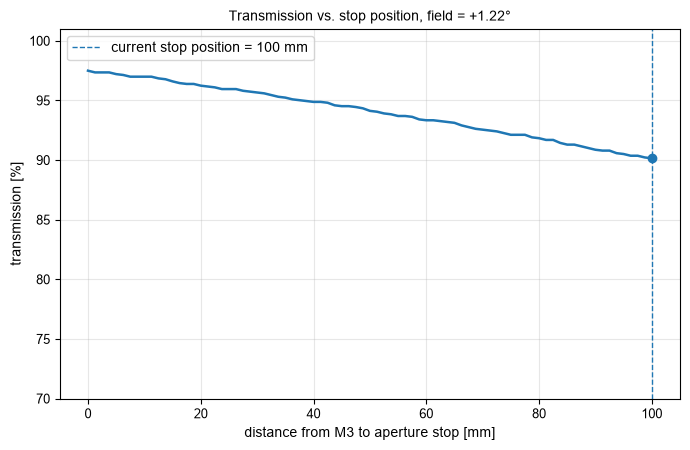

In [61]:
# Transmission at +SCAN field as a function of the M3-to-stop distance

STOP_SCAN = 1.22       # field angle [deg]
STOP_DISTANCES = np.linspace(0.0, 200.0, 81)   # STOP_AFTER_M3 [mm]
EPD_SCAN = BEAM
N_RAYS = 30


def trace_field_vs_stop(stop_after_m3, epd=EPD_SCAN, n=N_RAYS):
    """Trace the +STOP_SCAN field for a specified M3-to-stop distance."""

    global Z_STOP, ARM_M1_TO_STOP

    # Update the geometry-dependent quantities used by build()/aiming.
    Z_STOP = Z3 + stop_after_m3
    ARM_M1_TO_STOP = X_TOTAL / np.cos(2 * a) + stop_after_m3

    o = build(
        theta=0.0,
        fields=((0.0, 0.0), (0.0, STOP_SCAN)),
        epd=epd,
    )

    o.trace(
        Hx=0.0,
        Hy=1.0,
        wavelength=WAVELENGTH,
        num_rays=n,
        distribution="hexapolar",
    )

    return o


transmission = []

for stop_dist in STOP_DISTANCES:
    o = trace_field_vs_stop(stop_dist)
    _, T = incremental_loss(o)
    transmission.append(T)

transmission = np.asarray(transmission)


# Plot
fig, ax = plt.subplots(figsize=(7.0, 4.6))

ax.plot(
    STOP_DISTANCES,
    transmission,
    lw=1.8,
)

ax.axvline(
    STOP_AFTER_M3,
    ls="--",
    lw=1.0,
    label=f"current stop position = {STOP_AFTER_M3:g} mm",
)

ax.scatter(
    [STOP_AFTER_M3],
    [np.interp(STOP_AFTER_M3, STOP_DISTANCES, transmission)],
    zorder=3,
)

ax.set_xlabel("distance from M3 to aperture stop [mm]")
ax.set_ylabel("transmission [%]")
ax.set_title(
    f"Transmission vs. stop position, "
    f"field = +{STOP_SCAN:g}°"
)

ax.set_ylim(70, 101)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

fig.savefig(
    "transmission_vs_stop_position.pdf",
    bbox_inches="tight",
)


## reset
stop_dist = 100
o = trace_field_vs_stop(stop_dist)
_, T = incremental_loss(o)
transmission.append(T)

In [62]:
stop_dist = 100

### 8.1 Ray diagrams at $\theta = 0$ and $\theta = 90^\circ$

`draw()` renders a flat projection, and the K's fold plane **rotates with the assembly**:
at $\theta = 0$ it lies in $YZ$, at $\theta = 90^\circ$ it has turned into $XZ$. Each
rotation is therefore drawn twice - once in its own fold plane, where the K shape is
visible, and once perpendicular to it, where the assembly looks like a plain straight-
through path. `draw()` normalises each field in the list correctly, so both scan signs are
drawn here.

This is the whole explanation of the $\theta$ dependence above. The scan fans in $YZ$, so:

- at $\theta = 0$ the fan lies **inside** the fold plane. The field bundles separate on the
  mirrors and the walk is magnified by $1/\sin\alpha = 2.06$ in the direction that has the
  least room. This is where M1 loses rays.
- at $\theta = 90^\circ$ the fan is **perpendicular** to the fold. The walk runs along the
  mirror's long, unforeshortened direction, where there is far more margin, and nothing
  clips.

M2 sits 43.3 mm off axis, so each panel is framed explicitly - matplotlib's autoscale
crops it otherwise.

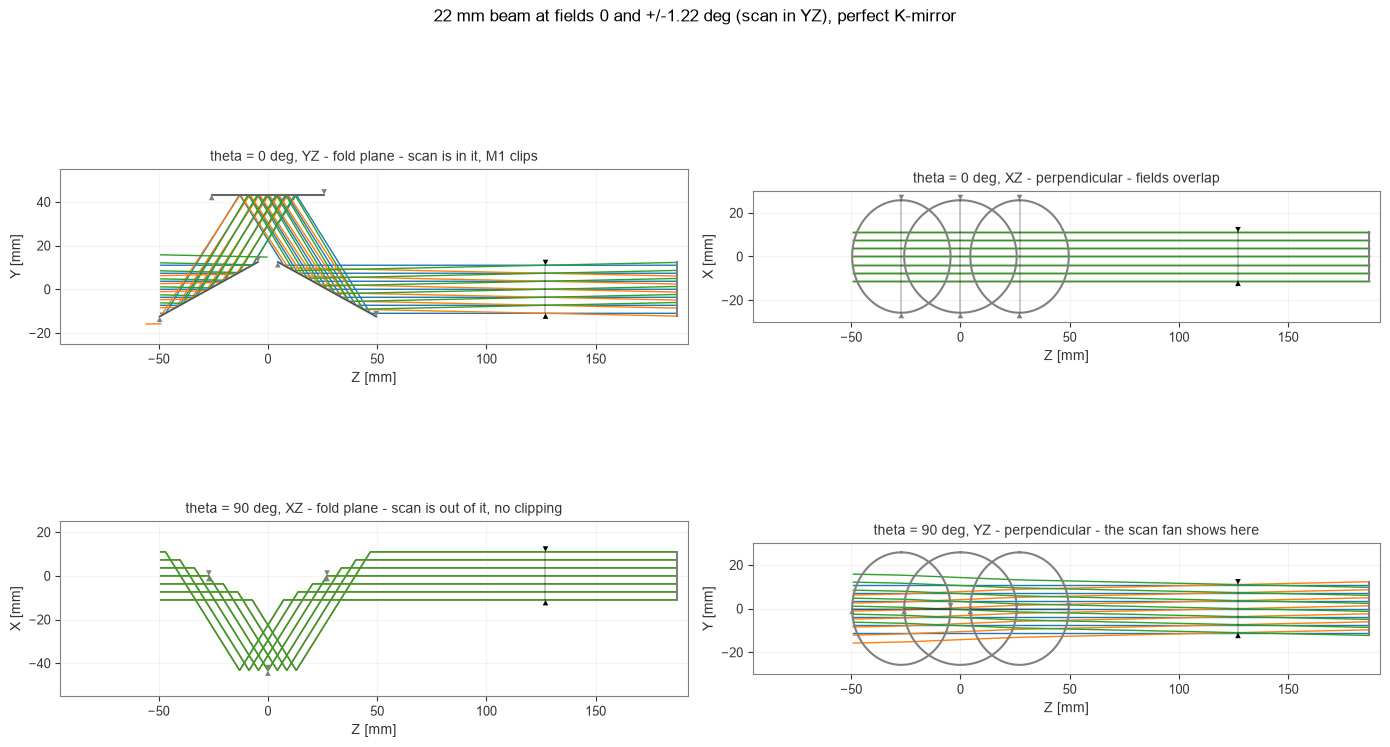

walk magnification in the fold plane = 1/sin(alpha) = 2.06


In [63]:
# M2 is at +H in y when theta = 0, and at -H in x when theta = 90 deg, so each
# panel needs its own framing; (theta, projection, cross-axis limits, note)
PANELS = [(0.0, "YZ", (-25, 55), "fold plane - scan is in it, M1 clips"),
          (0.0, "XZ", (-30, 30), "perpendicular - fields overlap"),
          (90.0, "XZ", (-55, 25), "fold plane - scan is out of it, no clipping"),
          (90.0, "YZ", (-30, 30), "perpendicular - the scan fan shows here")]

fig, axes = plt.subplots(2, 2, figsize=(14, 8.5))
for ax, (th, proj, lim, note) in zip(axes.ravel(), PANELS):
    o = build(theta=th, fields=((0.0, 0.0), (0.0, SCAN), (0.0, -SCAN)),
              screen=60.0, epd=BEAM)
    o.draw(num_rays=7, projection=proj, ax=ax, show_apertures=True,
           title=f"theta = {th:g} deg, {proj} - {note}")
    ax.set_ylim(*lim)
    ax.set_xlim(-95, Z_STOP + 65)
    ax.set_aspect("equal")
fig.suptitle(f"{BEAM:g} mm beam at fields 0 and +/-{SCAN} deg (scan in YZ), "
             f"perfect K-mirror")
plt.tight_layout()
plt.show()
fig.savefig("figure.pdf", bbox_inches="tight")
print(f"walk magnification in the fold plane = 1/sin(alpha) = {1 / np.sin(a):.2f}")

In [64]:
TH_WORST = 0

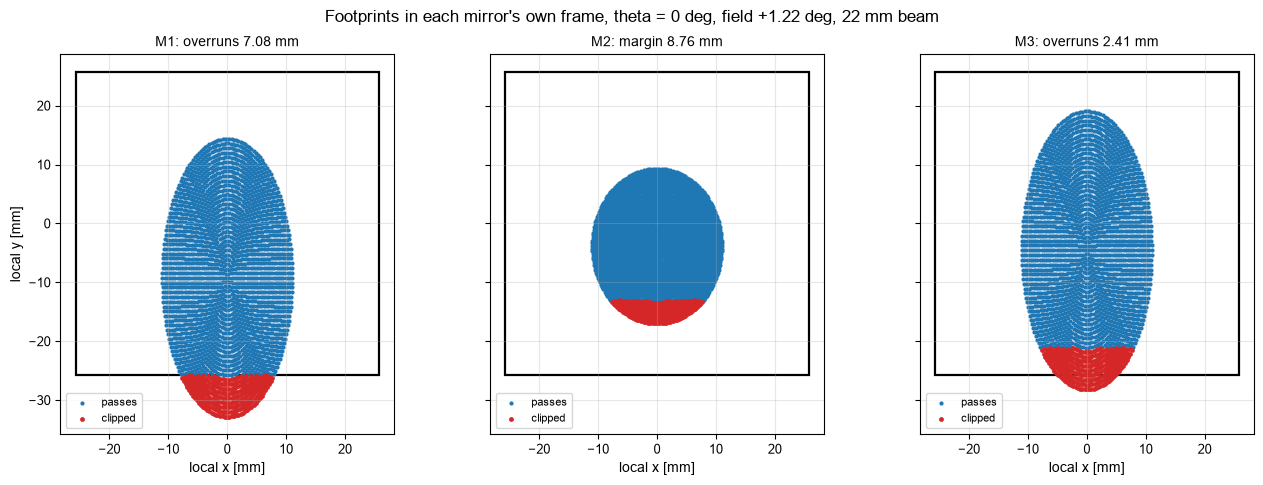

 mirror       footprint y extent   half-size    overrun
     M1     -32.83 ..  +14.36 mm     25.75 mm     +7.08 mm
     M2     -16.99 ..   +9.30 mm     25.75 mm     -8.76 mm
     M3     -28.16 ..  +19.03 mm     25.75 mm     +2.41 mm

analytic estimate: d <= L*sin(alpha) - 2*walk = 16.36 mm (optimistic - see below)
largest beam that passes 100% over the full scan, all theta, both signs:
   13.0 mm -> 100.00%
   14.0 mm -> 100.00%
   15.0 mm -> 100.00%
   16.0 mm ->  99.13%   <- clips
   17.0 mm ->  97.70%   <- clips
   18.0 mm ->  96.19%   <- clips
   19.0 mm ->  94.61%   <- clips
   20.0 mm ->  92.78%   <- clips
   21.0 mm ->  91.20%   <- clips
   22.0 mm ->  90.09%   <- clips
   23.0 mm ->  88.58%   <- clips


In [65]:
# --- footprints at the worst case ----------------------------------------
o = trace_field(TH_WORST, H_WORST, n=30)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.8), sharex=True, sharey=True)
for ax, (idx, name) in zip(axes, [(1, "M1"), (2, "M2"), (3, "M3")]):
    lx, ly, ii = local_xy(o, idx)
    ok = ii > 0
    ax.add_patch(plt.Rectangle((-L / 2, -L / 2), L, L, fill=False, ec="k", lw=1.6))
    ax.scatter(lx[ok], ly[ok], s=4, c="tab:blue", label="passes")
    if (~ok).any():
        ax.scatter(lx[~ok], ly[~ok], s=6, c="tab:red", label="clipped")
    over = max(np.abs(lx).max(), np.abs(ly).max()) - L / 2
    ax.set_title(f"{name}: {'overruns' if over > 0 else 'margin'} "
                 f"{abs(over):.2f} mm")
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.set_xlabel("local x [mm]")
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("local y [mm]")
fig.suptitle(f"Footprints in each mirror's own frame, theta = {TH_WORST:g} deg, "
             f"field {H_WORST * SCAN:+.2f} deg, {BEAM:g} mm beam")
plt.tight_layout()
plt.show()

print(f"{'mirror':>7} {'footprint y extent':>24} {'half-size':>11} {'overrun':>10}")
for idx, name in ((1, "M1"), (2, "M2"), (3, "M3")):
    lx, ly, _ = local_xy(o, idx)          # all rays, including the clipped ones
    over = max(ly.max(), -ly.min()) - L / 2
    print(f"{name:>7} {ly.min():+10.2f} .. {ly.max():+7.2f} mm {L / 2:9.2f} mm "
          f"{over:+9.2f} mm")

# --- how large a beam clears the whole scan ------------------------------
walk = ARM_M1_TO_STOP * np.tan(np.radians(SCAN))
print(f"\nanalytic estimate: d <= L*sin(alpha) - 2*walk = "
      f"{L * np.sin(a) - 2 * walk:.2f} mm (optimistic - see below)")
print("largest beam that passes 100% over the full scan, all theta, both signs:")
for d in np.arange(13.0, 23.01, 1.0):
    tmin = 100.0
    for t in np.arange(0, 360, 15.0):
        for h in (-1.0, 1.0):
            tmin = min(tmin, incremental_loss(trace_field(t, h, epd=d, n=20))[1])
    print(f"  {d:5.1f} mm -> {tmin:6.2f}%" + ("   <- clips" if tmin < 99.999 else ""))

fig.savefig("beam_clip_3_mirrors.pdf", bbox_inches="tight")

### Reading the result

- **M2 alone aligns the K-mirror to its rotation axis.** This is the main result. Fitting
  M2's two tilts to a random tolerance state cancels the *entire* $1\theta$ wobble - every
  mirror error, M1's and M3's included, not just M2's own - and the corrected locus lands
  on the bearing-only $2\theta$ floor to three digits on all 30 draws. What survives is
  exactly the misalignment of the **rotation axis** relative to the beam, and nothing else.
  So the three mirrors do not need to be individually accurate: they need to be
  *adjustable at M2*, and the K-mirror is then aligned as a unit against its own bearing.
- **What the M2 adjustment costs and cannot do.** The fit wants a median $0.083^\circ$ of
  M2 tilt and exceeds the $\pm0.1^\circ$ tolerance band on 37 % of draws, so the
  compensator needs roughly twice the tolerance in range. It buys pointing by driving M2
  further from nominal, which matters if anything else depends on the mirror angles. And
  it is blind to the $2\theta$ term by construction: M2 spins with the assembly, so its
  response is $1\theta$, and no static tilt of any mirror can reach a lab-fixed error.
- **Tilt grows with distance, decenter does not.**
- **The section 7 ranking describes the instrument only *before* it is adjusted.** There,
  ten roughly comparable terms share the variance and no single one dominates - which would
  suggest that halving the pointing error means halving *all* the angular tolerances. That
  conclusion does not survive section 7.1: eight of those ten terms are removable by one
  adjustment. Read section 7 as the as-built error, and the two bearing terms as the
  aligned one.
- **After alignment, the bearing tip is the whole problem.** Only four DOFs remain, and
  the two tips carry about 93 % of the residual variance against 7 % for the two decenters. Tightening the mirror
  tolerances buys nothing once M2 is adjustable; tightening the **bearing** tolerance is
  the only lever left.
- **Out-of-plane mirror terms are cheap** in the as-built state. $\varepsilon_y$ on M1 and
  M3 costs only $\cos(61^\circ) = 0.485$ of the in-plane term, because three reflections
  flip one transverse axis and preserve the other: the in-fold-plane component of a
  co-rotating error **doubles** while the perpendicular component largely **cancels**.
- **The decenter tolerance is nearly free**, before adjustment (1.4 % of the variance) and
  after it (7 % of what remains). Relaxing $\pm1$ mm to $\pm3$ mm would still leave it a
  minor term; tightening it to $\pm0.1$ mm would buy nothing measurable.


## Assumptions and caveats

- **$\alpha = 29^\circ$**, $L = 51.5$, $T = 6.25$, $X_{buffer} = 3$ mm, from the design
   text. Change `ALPHA` at the top to re-run everything for another angle.
- **The input beam is the reference axis** and is perfectly on-axis by construction. All
   misalignment sits on the K-mirror, so "pointing error" always means the exit beam's
   departure from the input beam's own line.
- **Pointing and clipping are kept separate.** Sections 5-7 measure the geometric axis -
   the axis ray of the input bundle - so aperture truncation does not enter any pointing
   result. Section 8 asks the complementary question, how much of the beam survives, and
   does so for a *perfectly aligned* K-mirror. The two are never combined: the loss of a
   misaligned K-mirror over the scan is not covered here.
- **Iterative ray aiming is on** for the field traces in sections 4 and 8. Turning it off
   silently reintroduces the 152 mm pupil-position error described in section 2. The
   pointing sections trace hand-built rays and set `aiming=None` deliberately.
- **Mirror thickness $T$ enters only through $X_{total}$** (eq. 2). The plates are not
   modelled as solid obstructions.
- **Wavelength is cosmetic** for a system of flats; 0.488 um only labels the trace.